<a href="https://colab.research.google.com/github/SuryaPachaiyappan1003/Abhibus/blob/main/python_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving ecommerce_analysis_summary.csv to ecommerce_analysis_summary.csv
Saving ecommerce_products.csv to ecommerce_products.csv
Saving ecommerce_products_final.csv to ecommerce_products_final.csv


In [ ]:
# STEP 2 - LOAD DATASET

df = pd.read_csv("ecommerce_products.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 500
Columns: 11


,Product_ID,Product_Name,Category,Sub_Category,Brand,Price,Discount_Percent,Rating,Review_Count,Stock,Selling_Price
0,P0001,Nike Running Shoes Essential,Sports,Running Shoes,Nike,4806,15,3.3,1621,456,4085.10
1,P0002,McGraw Hill Novel Premium,Books,Novel,McGraw Hill,280,1,3.0,10,119,277.20
2,P0003,Penguin Academic Book Max,Books,Academic Book,Penguin,964,45,4.2,851,301,530.20
3,P0004,Puma T-Shirt Essential,Fashion,T-Shirt,Puma,3862,21,3.4,1524,110,3050.98
4,P0005,Tata Dry Fruits Pro,Grocery,Dry Fruits,Tata,1656,6,3.6,1189,22,1556.64


In [ ]:
# STEP 3 - DATA INSPECTION

print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product_ID        500 non-null    object 
 1   Product_Name      500 non-null    object 
 2   Category          500 non-null    object 
 3   Sub_Category      500 non-null    object 
 4   Brand             500 non-null    object 
 5   Price             500 non-null    int64  
 6   Discount_Percent  500 non-null    int64  
 7   Rating            500 non-null    float64
 8   Review_Count      500 non-null    int64  
 9   Stock             500 non-null    int64  
 10  Selling_Price     500 non-null    float64
dtypes: float64(2), int64(4), object(5)
memory usage: 43.1+ KB

Missing Values:
Product_ID          0
Product_Name        0
Category            0
Sub_Category        0
Brand               0
Price               0
Discount_Percent    0
Rating              0
Review_

In [ ]:
# STEP 4 - DATA CLEANING

df = df.drop_duplicates()
df = df.dropna()

text_columns = [
    "Product_Name",
    "Category",
    "Sub_Category",
    "Brand"
]

for column in text_columns:
    df[column] = df[column].str.strip()

print("Data cleaning completed!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Data cleaning completed!
Rows: 500
Columns: 11


In [ ]:
# STEP 5 - BASIC STATISTICAL ANALYSIS

print("--- NUMERICAL SUMMARY ---")

df.describe()

--- NUMERICAL SUMMARY ---


,Price,Discount_Percent,Rating,Review_Count,Stock,Selling_Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,10059.748000,24.954000,3.894200,1836.558000,257.456000,7470.073180
std,18701.601971,14.919822,0.654923,1327.372582,143.967696,13981.934419
min,121.000000,0.000000,2.800000,10.000000,0.000000,114.950000
25%,1445.750000,13.000000,3.300000,800.750000,128.750000,1051.717500
50%,2954.000000,25.000000,3.900000,1773.000000,254.000000,2182.465000
75%,7307.000000,38.000000,4.500000,2657.000000,388.250000,5653.760000
max,88384.000000,50.000000,5.000000,5770.000000,499.000000,85732.480000


In [ ]:
# STEP 6 - CATEGORY ANALYSIS

category_analysis = df.groupby("Category").agg(
    Product_Count=("Product_ID", "count"),
    Average_Price=("Price", "mean"),
    Average_Rating=("Rating", "mean"),
    Total_Reviews=("Review_Count", "sum")
).round(2)

print("--- CATEGORY ANALYSIS ---")
category_analysis

--- CATEGORY ANALYSIS ---


,Product_Count,Average_Price,Average_Rating,Total_Reviews
Category,,,,
Beauty,73,2138.60,3.88,128195
Books,72,1326.85,3.88,124490
Electronics,68,50396.10,4.05,116066
Fashion,69,4370.33,3.97,138774
Grocery,71,1400.31,3.89,137327
Home & Kitchen,65,8318.92,3.86,125369
Sports,82,4994.91,3.75,148058


In [ ]:
# STEP 7 - TOP 10 MOST REVIEWED PRODUCTS

top_reviewed = df.sort_values(
    by="Review_Count",
    ascending=False
).head(10)

print("--- TOP 10 MOST REVIEWED PRODUCTS ---")

top_reviewed[
    ["Product_Name", "Category", "Rating", "Review_Count"]
]

--- TOP 10 MOST REVIEWED PRODUCTS ---


,Product_Name,Category,Rating,Review_Count
225,Nike Running Shoes Essential,Sports,3.9,5770
249,Maybelline Shampoo Pro,Beauty,3.9,5715
97,Adidas Jeans Pro,Fashion,4.1,5544
137,Lakme Shampoo Max,Beauty,4.5,5511
201,Dove Moisturizer Essential,Beauty,3.8,5425
495,Maybelline Sunscreen Plus,Beauty,3.2,5348
314,Puma Jeans Essential,Fashion,3.2,5074
78,Organic Tattva Snacks Pro,Grocery,4.4,5066
444,Yonex Dumbbells Max,Sports,4.1,5023
451,Adidas Jeans Plus,Fashion,4.0,4929


In [ ]:
# STEP 8 - PRICE ANALYSIS

print("--- PRICE ANALYSIS ---")

print("Average Price:", round(df["Price"].mean(), 2))
print("Minimum Price:", df["Price"].min())
print("Maximum Price:", df["Price"].max())
print("Average Selling Price:", round(df["Selling_Price"].mean(), 2))

--- PRICE ANALYSIS ---
Average Price: 10059.75
Minimum Price: 121
Maximum Price: 88384
Average Selling Price: 7470.07


In [ ]:
# STEP 9 - RATING AND REVIEW ANALYSIS

print("--- RATING ANALYSIS ---")

print("Average Rating:", round(df["Rating"].mean(), 2))
print("Highest Rating:", df["Rating"].max())
print("Lowest Rating:", df["Rating"].min())

print("\n--- CATEGORY WISE AVERAGE RATING ---")

category_rating = df.groupby("Category")["Rating"].mean().round(2)

print(category_rating)

--- RATING ANALYSIS ---
Average Rating: 3.89
Highest Rating: 5.0
Lowest Rating: 2.8

--- CATEGORY WISE AVERAGE RATING ---
Category
Beauty            3.88
Books             3.88
Electronics       4.05
Fashion           3.97
Grocery           3.89
Home & Kitchen    3.86
Sports            3.75
Name: Rating, dtype: float64


In [ ]:
# STEP 10 - CATEGORY WISE PRODUCT COUNT

category_count = df["Category"].value_counts()

print("--- PRODUCT COUNT BY CATEGORY ---")
print(category_count)

--- PRODUCT COUNT BY CATEGORY ---
Category
Sports            82
Beauty            73
Books             72
Grocery           71
Fashion           69
Electronics       68
Home & Kitchen    65
Name: count, dtype: int64


In [ ]:
# STEP 11 - CATEGORY WISE AVERAGE PRICE

category_price = df.groupby("Category")["Price"].mean().round(2)

print("--- CATEGORY WISE AVERAGE PRICE ---")
print(category_price)

--- CATEGORY WISE AVERAGE PRICE ---
Category
Beauty             2138.60
Books              1326.85
Electronics       50396.10
Fashion            4370.33
Grocery            1400.31
Home & Kitchen     8318.92
Sports             4994.91
Name: Price, dtype: float64


In [ ]:
# STEP 12 - TOP 10 MOST EXPENSIVE PRODUCTS

top_expensive = df.sort_values(
    by="Price",
    ascending=False
).head(10)

print("--- TOP 10 MOST EXPENSIVE PRODUCTS ---")

top_expensive[
    ["Product_Name", "Category", "Brand", "Price", "Selling_Price"]
]

--- TOP 10 MOST EXPENSIVE PRODUCTS ---


,Product_Name,Category,Brand,Price,Selling_Price
315,Samsung Tablet Pro,Electronics,Samsung,88384,85732.48
215,HP Headphones Essential,Electronics,HP,86927,52156.20
242,Lenovo Smartphone Classic,Electronics,Lenovo,86144,74945.28
347,boAt Laptop Plus,Electronics,boAt,85603,52217.83
16,Lenovo Smartphone Classic,Electronics,Lenovo,84812,67001.48
210,HP Smartphone Premium,Electronics,HP,84548,42274.00
214,Apple Smartwatch Pro,Electronics,Apple,84118,63929.68
396,Lenovo Smartwatch Classic,Electronics,Lenovo,83188,45753.40
338,boAt Headphones Plus,Electronics,boAt,82724,57079.56
127,boAt Smartwatch Classic,Electronics,boAt,82491,46194.96


In [ ]:
# STEP 13 - DISCOUNT ANALYSIS

print("--- DISCOUNT ANALYSIS ---")

print("Average Discount:", round(df["Discount_Percent"].mean(), 2))
print("Highest Discount:", df["Discount_Percent"].max())
print("Lowest Discount:", df["Discount_Percent"].min())

print("\n--- TOP 10 PRODUCTS WITH HIGHEST DISCOUNT ---")

top_discount = df.sort_values(
    by="Discount_Percent",
    ascending=False
).head(10)

top_discount[
    ["Product_Name", "Category", "Price",
     "Discount_Percent", "Selling_Price"]
]

--- DISCOUNT ANALYSIS ---
Average Discount: 24.95
Highest Discount: 50
Lowest Discount: 0

--- TOP 10 PRODUCTS WITH HIGHEST DISCOUNT ---


,Product_Name,Category,Price,Discount_Percent,Selling_Price
342,Organic Tattva Tea Premium,Grocery,1248,50,624.00
210,HP Smartphone Premium,Electronics,84548,50,42274.00
152,boAt Smartphone Plus,Electronics,17305,50,8652.50
153,Oxford Programming Book Classic,Books,754,50,377.00
143,Cosco Football Classic,Sports,1779,50,889.50
278,Adidas Cricket Bat Pro,Sports,5823,50,2911.50
213,Allen Solly T-Shirt Max,Fashion,4556,50,2278.00
320,Pearson Academic Book Classic,Books,1244,50,622.00
433,Adidas T-Shirt Max,Fashion,3328,49,1697.28
209,Cosco Dumbbells Premium,Sports,2121,49,1081.71


In [ ]:
# STEP 14 - SELLING PRICE ANALYSIS

print("--- SELLING PRICE ANALYSIS ---")

print("Average Selling Price:", round(df["Selling_Price"].mean(), 2))
print("Minimum Selling Price:", df["Selling_Price"].min())
print("Maximum Selling Price:", df["Selling_Price"].max())

print("\n--- TOP 10 PRODUCTS BY SELLING PRICE ---")

top_selling = df.sort_values(
    by="Selling_Price",
    ascending=False
).head(10)

top_selling[
    ["Product_Name", "Category", "Brand",
     "Selling_Price", "Rating", "Review_Count"]
]

--- SELLING PRICE ANALYSIS ---
Average Selling Price: 7470.07
Minimum Selling Price: 114.95
Maximum Selling Price: 85732.48

--- TOP 10 PRODUCTS BY SELLING PRICE ---


,Product_Name,Category,Brand,Selling_Price,Rating,Review_Count
315,Samsung Tablet Pro,Electronics,Samsung,85732.48,4.5,10
242,Lenovo Smartphone Classic,Electronics,Lenovo,74945.28,4.5,69
16,Lenovo Smartphone Classic,Electronics,Lenovo,67001.48,3.0,387
403,Apple Headphones Classic,Electronics,Apple,66683.52,3.4,4699
53,boAt Smartphone Plus,Electronics,boAt,64595.16,2.9,10
214,Apple Smartwatch Pro,Electronics,Apple,63929.68,5.0,1794
381,HP Smartphone Premium,Electronics,HP,60636.00,5.0,3235
253,Lenovo Smartwatch Premium,Electronics,Lenovo,60482.10,4.6,1296
25,boAt Smartphone Pro,Electronics,boAt,57962.35,3.4,2652
338,boAt Headphones Plus,Electronics,boAt,57079.56,4.1,2023


In [ ]:
# STEP 15 - STOCK ANALYSIS

print("--- STOCK ANALYSIS ---")

print("Average Stock:", round(df["Stock"].mean(), 2))
print("Minimum Stock:", df["Stock"].min())
print("Maximum Stock:", df["Stock"].max())

print("\n--- TOP 10 PRODUCTS WITH HIGHEST STOCK ---")

top_stock = df.sort_values(
    by="Stock",
    ascending=False
).head(10)

top_stock[
    ["Product_Name", "Category", "Brand",
     "Stock", "Price", "Selling_Price"]
]

--- STOCK ANALYSIS ---
Average Stock: 257.46
Minimum Stock: 0
Maximum Stock: 499

--- TOP 10 PRODUCTS WITH HIGHEST STOCK ---


,Product_Name,Category,Brand,Stock,Price,Selling_Price
403,Apple Headphones Classic,Electronics,Apple,499,69462,66683.52
137,Lakme Shampoo Max,Beauty,Lakme,498,3693,2105.01
323,Apple Smartwatch Essential,Electronics,Apple,498,44220,28300.80
111,Nivea Shampoo Max,Beauty,Nivea,496,1935,1161.00
480,Philips Air Fryer Essential,Home & Kitchen,Philips,495,3887,3226.21
231,Nestle Coffee Plus,Grocery,Nestle,495,1923,1826.85
249,Maybelline Shampoo Pro,Beauty,Maybelline,494,518,388.50
340,Aashirvaad Organic Rice Classic,Grocery,Aashirvaad,493,1413,876.06
157,McGraw Hill Programming Book Pro,Books,McGraw Hill,493,2285,1850.85
134,Minimalist Shampoo Plus,Beauty,Minimalist,492,452,325.44


In [ ]:
# STEP 16 - CATEGORY WISE STOCK ANALYSIS

category_stock = df.groupby("Category")["Stock"].agg(
    ["mean", "min", "max"]
).round(2)

print("--- CATEGORY WISE STOCK ---")
category_stock

--- CATEGORY WISE STOCK ---


,mean,min,max
Category,,,
Beauty,272.45,9,498
Books,252.06,0,493
Electronics,289.37,10,499
Fashion,265.28,45,491
Grocery,245.41,18,495
Home & Kitchen,256.00,22,495
Sports,227.39,1,476


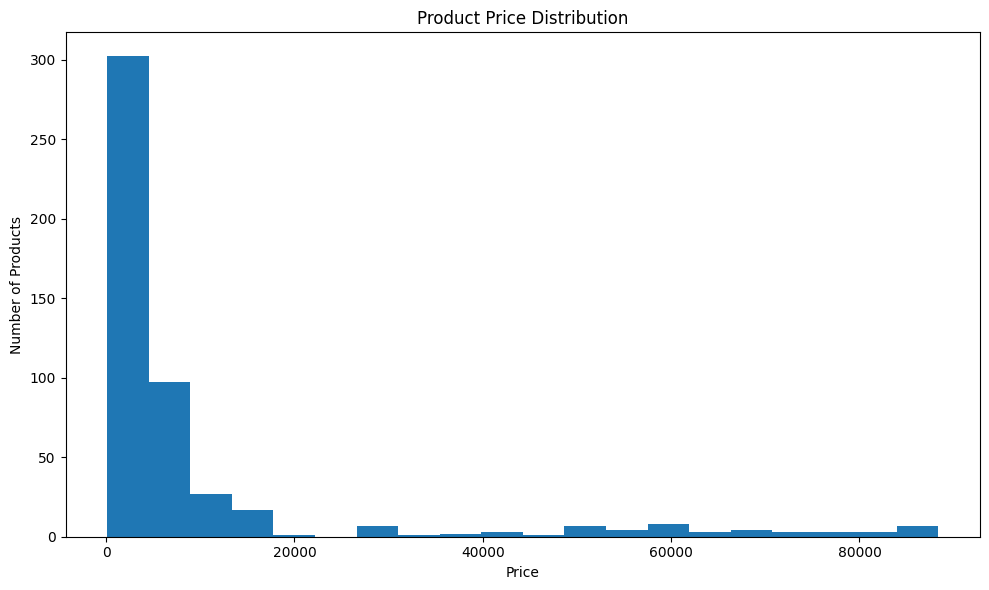

In [ ]:
# STEP 17 - PRICE DISTRIBUTION

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df["Price"], bins=20)

plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

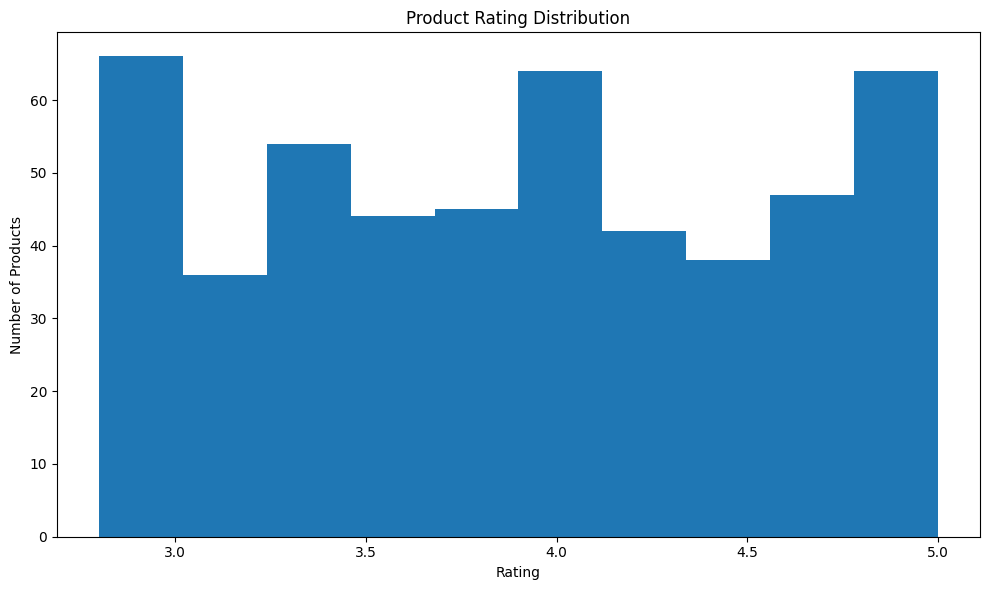

In [ ]:
# STEP 18 - RATING DISTRIBUTION

plt.figure(figsize=(10, 6))

plt.hist(df["Rating"], bins=10)

plt.title("Product Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

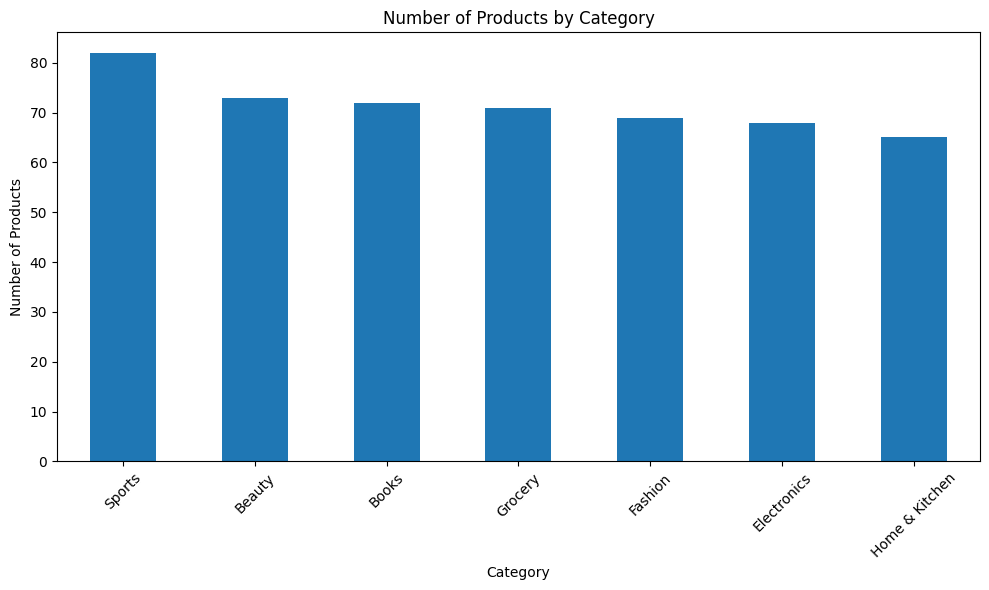

In [ ]:
# STEP 19 - CATEGORY WISE PRODUCT COUNT CHART

category_count = df["Category"].value_counts()

plt.figure(figsize=(10, 6))

category_count.plot(kind="bar")

plt.title("Number of Products by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

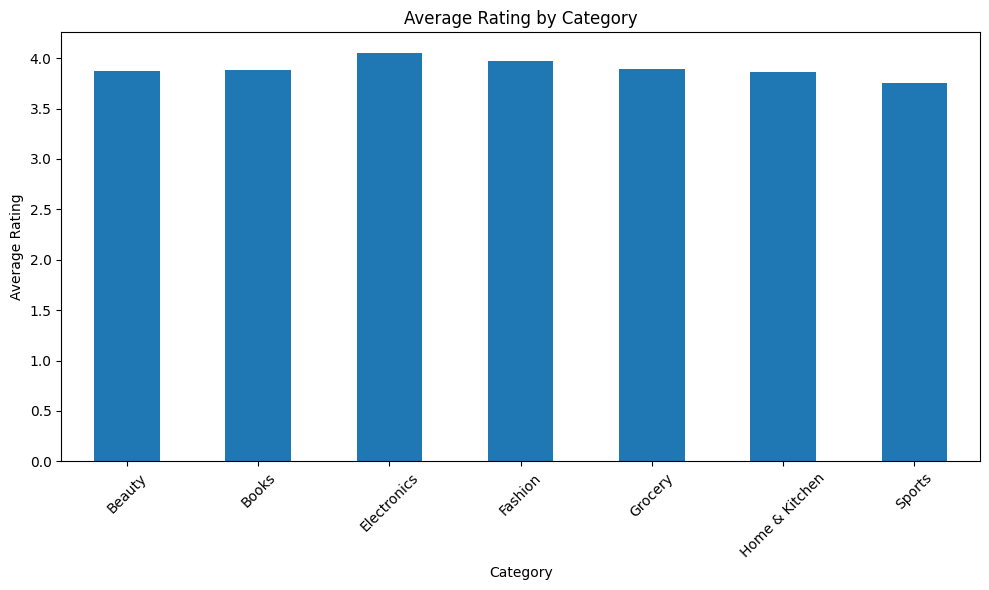

In [ ]:
# STEP 20 - CATEGORY WISE AVERAGE RATING CHART

category_rating = df.groupby("Category")["Rating"].mean()

plt.figure(figsize=(10, 6))

category_rating.plot(kind="bar")

plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

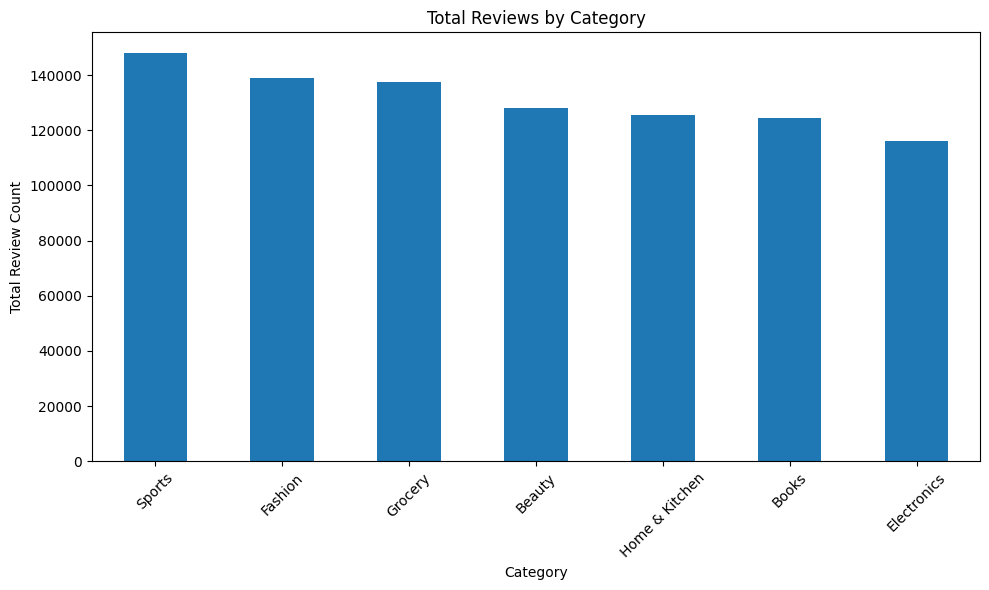

In [ ]:
# STEP 21 - CATEGORY WISE TOTAL REVIEWS

category_reviews = df.groupby("Category")["Review_Count"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

category_reviews.plot(kind="bar")

plt.title("Total Reviews by Category")
plt.xlabel("Category")
plt.ylabel("Total Review Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

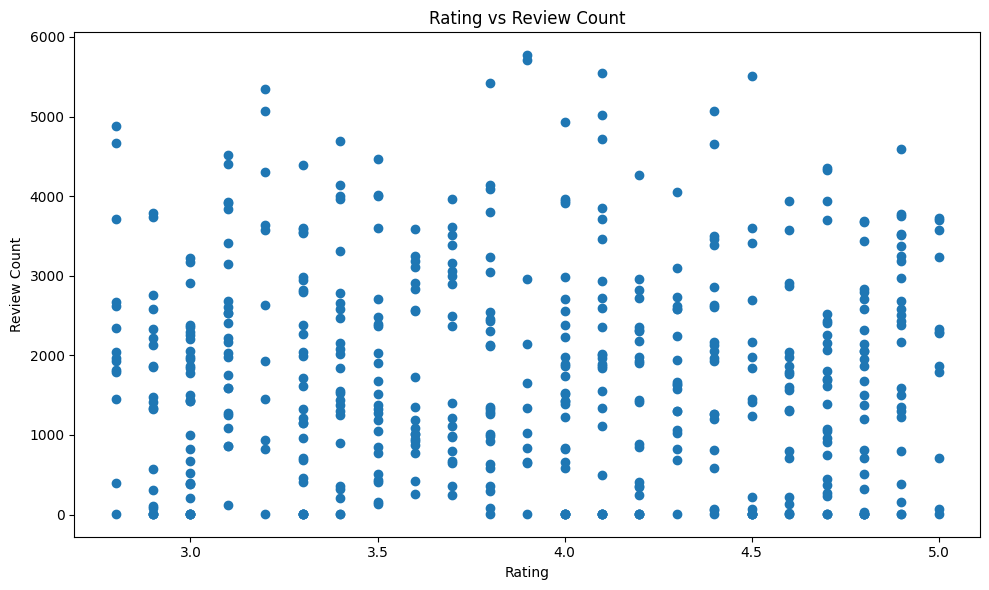

In [ ]:
# STEP 22 - RATING VS REVIEW COUNT

plt.figure(figsize=(10, 6))

plt.scatter(df["Rating"], df["Review_Count"])

plt.title("Rating vs Review Count")
plt.xlabel("Rating")
plt.ylabel("Review Count")

plt.tight_layout()
plt.show()

In [ ]:
# STEP 23 - CATEGORY WISE AVERAGE SELLING PRICE

category_selling = df.groupby("Category")["Selling_Price"].mean().sort_values(
    ascending=False
).round(2)

print("--- CATEGORY WISE AVERAGE SELLING PRICE ---")
print(category_selling)

--- CATEGORY WISE AVERAGE SELLING PRICE ---
Category
Electronics       37061.19
Home & Kitchen     6396.37
Sports             3819.68
Fashion            3240.68
Beauty             1584.36
Grocery            1051.26
Books               999.90
Name: Selling_Price, dtype: float64


In [ ]:
# STEP 24 - BEST PERFORMING PRODUCTS

best_products = df[
    (df["Rating"] >= 4.5) &
    (df["Review_Count"] >= 2000)
].sort_values(
    by="Review_Count",
    ascending=False
).head(10)

print("--- TOP 10 BEST PERFORMING PRODUCTS ---")

best_products[
    ["Product_Name", "Category", "Brand",
     "Rating", "Review_Count", "Selling_Price"]
]

--- TOP 10 BEST PERFORMING PRODUCTS ---


,Product_Name,Category,Brand,Rating,Review_Count,Selling_Price
137,Lakme Shampoo Max,Beauty,Lakme,4.5,5511,2105.01
268,Nivea Shampoo Classic,Beauty,Nivea,4.9,4594,264.04
494,Lenovo Smartwatch Classic,Electronics,Lenovo,4.7,4351,53297.62
48,McGraw Hill Self Help Book Essential,Books,McGraw Hill,4.7,4326,665.55
420,Adidas Jeans Classic,Fashion,Adidas,4.7,3942,3523.80
95,Cosco Dumbbells Max,Sports,Cosco,4.6,3940,4639.84
239,Penguin Business Book Classic,Books,Penguin,4.9,3775,572.40
373,McGraw Hill Business Book Essential,Books,McGraw Hill,4.9,3754,496.80
213,Allen Solly T-Shirt Max,Fashion,Allen Solly,5.0,3720,2278.00
428,Puma Jeans Classic,Fashion,Puma,4.7,3699,1938.24


In [ ]:
# STEP 25 - DISCOUNT AMOUNT

df["Discount_Amount"] = df["Price"] - df["Selling_Price"]

print("--- DISCOUNT AMOUNT ANALYSIS ---")

print("Average Discount Amount:",
      round(df["Discount_Amount"].mean(), 2))

print("Maximum Discount Amount:",
      round(df["Discount_Amount"].max(), 2))

print("\n--- TOP 10 PRODUCTS BY DISCOUNT AMOUNT ---")

top_discount_amount = df.sort_values(
    by="Discount_Amount",
    ascending=False
).head(10)

top_discount_amount[
    ["Product_Name", "Category", "Price",
     "Discount_Percent", "Discount_Amount", "Selling_Price"]
]

--- DISCOUNT AMOUNT ANALYSIS ---
Average Discount Amount: 2589.67
Maximum Discount Amount: 42274.0

--- TOP 10 PRODUCTS BY DISCOUNT AMOUNT ---


,Product_Name,Category,Price,Discount_Percent,Discount_Amount,Selling_Price
210,HP Smartphone Premium,Electronics,84548,50,42274.00,42274.00
396,Lenovo Smartwatch Classic,Electronics,83188,45,37434.60,45753.40
127,boAt Smartwatch Classic,Electronics,82491,44,36296.04,46194.96
215,HP Headphones Essential,Electronics,86927,40,34770.80,52156.20
94,boAt Laptop Pro,Electronics,71036,48,34097.28,36938.72
347,boAt Laptop Plus,Electronics,85603,39,33385.17,52217.83
105,boAt Laptop Essential,Electronics,78104,42,32803.68,45300.32
452,Lenovo Headphones Max,Electronics,64073,45,28832.85,35240.15
460,boAt Smartphone Max,Electronics,55062,48,26429.76,28632.24
338,boAt Headphones Plus,Electronics,82724,31,25644.44,57079.56


In [ ]:
# STEP 26 - CORRELATION ANALYSIS

correlation = df[
    ["Price", "Discount_Percent", "Rating",
     "Review_Count", "Stock", "Selling_Price"]
].corr().round(2)

print("--- CORRELATION ANALYSIS ---")
correlation

--- CORRELATION ANALYSIS ---


,Price,Discount_Percent,Rating,Review_Count,Stock,Selling_Price
Price,1.00,0.03,0.04,-0.04,0.04,0.98
Discount_Percent,0.03,1.00,0.03,0.02,-0.01,-0.08
Rating,0.04,0.03,1.00,-0.02,-0.02,0.04
Review_Count,-0.04,0.02,-0.02,1.00,-0.00,-0.04
Stock,0.04,-0.01,-0.02,-0.00,1.00,0.05
Selling_Price,0.98,-0.08,0.04,-0.04,0.05,1.00


In [ ]:
# STEP 27 - SALES POTENTIAL ANALYSIS

df["Sales_Potential"] = df["Selling_Price"] * df["Stock"]

top_sales = df.sort_values(
    by="Sales_Potential",
    ascending=False
).head(10)

print("--- TOP 10 PRODUCTS BY SALES POTENTIAL ---")

top_sales[
    ["Product_Name", "Category",
     "Selling_Price", "Stock", "Sales_Potential"]
]

--- TOP 10 PRODUCTS BY SALES POTENTIAL ---


,Product_Name,Category,Selling_Price,Stock,Sales_Potential
403,Apple Headphones Classic,Electronics,66683.52,499,33275076.48
16,Lenovo Smartphone Classic,Electronics,67001.48,488,32696722.24
214,Apple Smartwatch Pro,Electronics,63929.68,403,25763661.04
256,boAt Laptop Premium,Electronics,48896.99,476,23274967.24
326,Lenovo Laptop Plus,Electronics,50884.80,434,22084003.20
161,HP Tablet Premium,Electronics,51587.96,423,21821707.08
401,Samsung Laptop Plus,Electronics,51374.70,400,20549880.00
477,HP Smartphone Classic,Electronics,40216.92,491,19746507.72
53,boAt Smartphone Plus,Electronics,64595.16,305,19701523.80
253,Lenovo Smartwatch Premium,Electronics,60482.10,319,19293789.90


In [ ]:
# STEP 28 - CATEGORY WISE SALES POTENTIAL

category_sales = df.groupby("Category")["Sales_Potential"].sum().sort_values(
    ascending=False
).round(2)

print("--- CATEGORY WISE SALES POTENTIAL ---")
print(category_sales)

--- CATEGORY WISE SALES POTENTIAL ---
Category
Electronics       7.010816e+08
Home & Kitchen    1.076096e+08
Sports            7.528775e+07
Fashion           5.963399e+07
Beauty            2.986916e+07
Books             1.826680e+07
Grocery           1.715812e+07
Name: Sales_Potential, dtype: float64


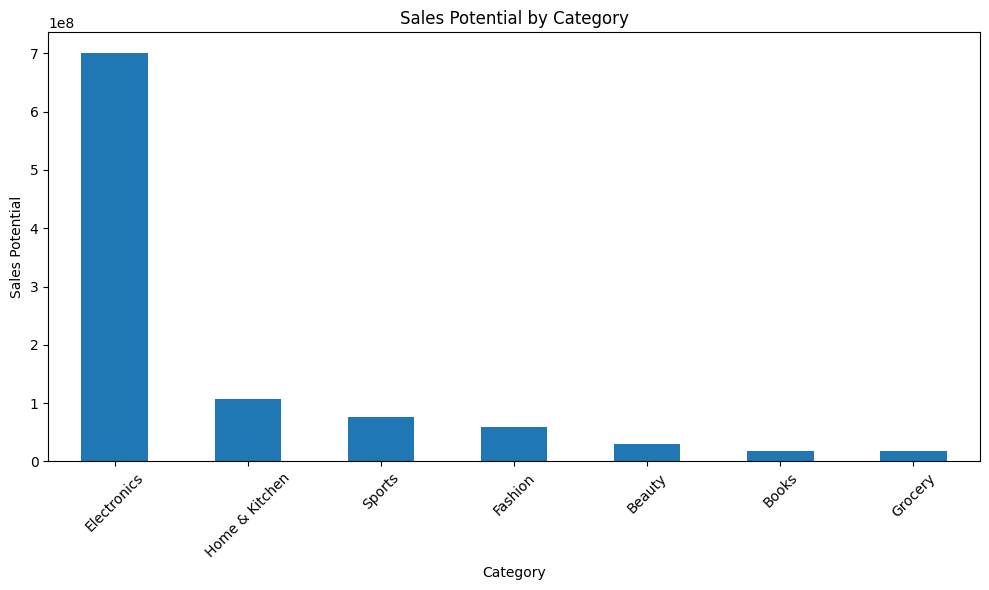

In [ ]:
# STEP 29 - CATEGORY WISE SALES POTENTIAL CHART

category_sales = df.groupby("Category")["Sales_Potential"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

category_sales.plot(kind="bar")

plt.title("Sales Potential by Category")
plt.xlabel("Category")
plt.ylabel("Sales Potential")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# STEP 30 - BRAND WISE PRODUCT COUNT

brand_count = df["Brand"].value_counts().head(10)

print("--- TOP 10 BRANDS BY PRODUCT COUNT ---")
print(brand_count)

--- TOP 10 BRANDS BY PRODUCT COUNT ---
Brand
Adidas         38
Nike           29
Puma           26
Cosco          23
boAt           22
Britannia      18
Tata           18
Dove           18
McGraw Hill    17
Bajaj          16
Name: count, dtype: int64


In [ ]:
# STEP 31 - BRAND WISE AVERAGE RATING

brand_rating = df.groupby("Brand")["Rating"].mean().sort_values(
    ascending=False
).round(2)

print("--- TOP 10 BRANDS BY AVERAGE RATING ---")
print(brand_rating.head(10))

--- TOP 10 BRANDS BY AVERAGE RATING ---
Brand
Samsung       4.29
Oxford        4.13
Nivea         4.12
Apple         4.08
Adidas        4.06
Nike          4.05
Minimalist    4.04
Bajaj         4.02
Lenovo        4.02
HP            4.00
Name: Rating, dtype: float64


In [ ]:
# STEP 32 - BRAND WISE TOTAL REVIEWS

brand_reviews = df.groupby("Brand")["Review_Count"].sum().sort_values(
    ascending=False
)

print("--- TOP 10 BRANDS BY TOTAL REVIEWS ---")
print(brand_reviews.head(10))

--- TOP 10 BRANDS BY TOTAL REVIEWS ---
Brand
Adidas            69762
Nike              61954
Cosco             44272
Bajaj             42504
Puma              40400
Britannia         38909
Allen Solly       38358
boAt              36590
Organic Tattva    32957
McGraw Hill       32411
Name: Review_Count, dtype: int64


In [ ]:
# STEP 33 - BRAND WISE AVERAGE SELLING PRICE

brand_selling_price = df.groupby("Brand")["Selling_Price"].mean().sort_values(
    ascending=False
).round(2)

print("--- TOP 10 BRANDS BY AVERAGE SELLING PRICE ---")
print(brand_selling_price.head(10))

--- TOP 10 BRANDS BY AVERAGE SELLING PRICE ---
Brand
HP          46494.08
Lenovo      42311.25
Apple       36322.64
boAt        34018.42
Samsung     33080.43
Bajaj        7558.41
Havells      6270.05
Philips      6052.67
Prestige     5894.24
Pigeon       5731.16
Name: Selling_Price, dtype: float64


In [ ]:
# STEP 34 - BRAND WISE AVERAGE DISCOUNT

brand_discount = df.groupby("Brand")["Discount_Percent"].mean().sort_values(
    ascending=False
).round(2)

print("--- TOP 10 BRANDS BY AVERAGE DISCOUNT ---")
print(brand_discount.head(10))

--- TOP 10 BRANDS BY AVERAGE DISCOUNT ---
Brand
Aashirvaad        32.92
boAt              32.50
Allen Solly       32.20
Lakme             31.00
Dove              29.06
Nivea             28.92
Organic Tattva    28.15
Pearson           27.85
Oxford            27.81
Adidas            26.87
Name: Discount_Percent, dtype: float64


In [ ]:
# STEP 35 - SUB-CATEGORY ANALYSIS

subcategory_analysis = df.groupby("Sub_Category").agg(
    Product_Count=("Product_ID", "count"),
    Average_Price=("Price", "mean"),
    Average_Rating=("Rating", "mean"),
    Total_Reviews=("Review_Count", "sum")
).round(2)

print("--- SUB-CATEGORY ANALYSIS ---")
subcategory_analysis

--- SUB-CATEGORY ANALYSIS ---


,Product_Count,Average_Price,Average_Rating,Total_Reviews
Sub_Category,,,,
Academic Book,14,1379.14,3.86,21380
Air Fryer,13,8056.92,3.95,23685
Business Book,12,1349.67,3.83,18863
Coffee,14,1603.36,3.99,27232
Coffee Maker,9,9784.56,3.88,19818
Cookware Set,15,7398.33,4.05,19638
Cricket Bat,20,5943.95,3.62,37764
Dry Fruits,14,1329.50,3.90,27612
Dumbbells,20,4026.15,3.78,42655


In [ ]:
# STEP 36 - TOP SUB-CATEGORIES BY PRODUCT COUNT

subcategory_count = df["Sub_Category"].value_counts().head(10)

print("--- TOP 10 SUB-CATEGORIES BY PRODUCT COUNT ---")
print(subcategory_count)

--- TOP 10 SUB-CATEGORIES BY PRODUCT COUNT ---
Sub_Category
Shampoo           22
Jeans             21
Cricket Bat       20
Dumbbells         20
T-Shirt           18
Smartphone        17
Self Help Book    17
Face Wash         16
Headphones        16
Football          16
Name: count, dtype: int64


In [ ]:
# STEP 37 - SUB-CATEGORY WISE AVERAGE RATING

subcategory_rating = df.groupby("Sub_Category")["Rating"].mean().sort_values(
    ascending=False
).round(2)

print("--- TOP 10 SUB-CATEGORIES BY AVERAGE RATING ---")
print(subcategory_rating.head(10))

--- TOP 10 SUB-CATEGORIES BY AVERAGE RATING ---
Sub_Category
Smartwatch      4.42
Tablet          4.29
T-Shirt         4.13
Jeans           4.05
Cookware Set    4.05
Headphones      4.03
Coffee          3.99
Novel           3.99
Yoga Mat        3.99
Tea             3.97
Name: Rating, dtype: float64


In [ ]:
# STEP 38 - SUB-CATEGORY WISE TOTAL REVIEWS

subcategory_reviews = df.groupby("Sub_Category")["Review_Count"].sum().sort_values(
    ascending=False
)

print("--- TOP 10 SUB-CATEGORIES BY TOTAL REVIEWS ---")
print(subcategory_reviews.head(10))

--- TOP 10 SUB-CATEGORIES BY TOTAL REVIEWS ---
Sub_Category
Jeans               53919
Shampoo             47944
Dumbbells           42655
Cricket Bat         37764
Vacuum Cleaner      37322
Smartphone          34929
Tea                 34197
Programming Book    32948
T-Shirt             30325
Self Help Book      28806
Name: Review_Count, dtype: int64


In [ ]:
# STEP 39 - SUB-CATEGORY WISE AVERAGE SELLING PRICE

subcategory_selling = df.groupby("Sub_Category")["Selling_Price"].mean().sort_values(
    ascending=False
).round(2)

print("--- TOP 10 SUB-CATEGORIES BY AVERAGE SELLING PRICE ---")
print(subcategory_selling.head(10))

--- TOP 10 SUB-CATEGORIES BY AVERAGE SELLING PRICE ---
Sub_Category
Laptop            40254.09
Tablet            38589.20
Smartphone        38510.15
Headphones        35848.75
Smartwatch        33454.05
Vacuum Cleaner     7569.56
Coffee Maker       7490.96
Air Fryer          6526.83
Cookware Set       5342.55
Mixer              5187.12
Name: Selling_Price, dtype: float64


In [ ]:
# STEP 40 - SUB-CATEGORY WISE AVERAGE DISCOUNT

subcategory_discount = df.groupby("Sub_Category")["Discount_Percent"].mean().sort_values(
    ascending=False
).round(2)

print("--- TOP 10 SUB-CATEGORIES BY AVERAGE DISCOUNT ---")
print(subcategory_discount.head(10))

--- TOP 10 SUB-CATEGORIES BY AVERAGE DISCOUNT ---
Sub_Category
Sunscreen       32.89
Handbag         30.55
Dry Fruits      29.93
Football        29.38
Cookware Set    28.80
T-Shirt         27.94
Tea             27.80
Smartphone      27.35
Smartwatch      27.13
Mixer           26.92
Name: Discount_Percent, dtype: float64


In [ ]:
# STEP 41 - BEST VALUE PRODUCTS

best_value = df.copy()

best_value["Value_Score"] = (
    best_value["Rating"] * best_value["Discount_Percent"]
)

best_value = best_value.sort_values(
    by="Value_Score",
    ascending=False
).head(10)

print("--- TOP 10 BEST VALUE PRODUCTS ---")

best_value[
    ["Product_Name", "Category", "Rating",
     "Discount_Percent", "Selling_Price", "Value_Score"]
]

--- TOP 10 BEST VALUE PRODUCTS ---


,Product_Name,Category,Rating,Discount_Percent,Selling_Price,Value_Score
213,Allen Solly T-Shirt Max,Fashion,5.0,50,2278.00,250.0
424,Tata Tea Pro,Grocery,5.0,49,179.52,245.0
153,Oxford Programming Book Classic,Books,4.8,50,377.00,240.0
467,Pigeon Air Fryer Max,Home & Kitchen,4.9,48,5223.92,235.2
194,Adidas Sneakers Plus,Fashion,4.9,45,2900.70,220.5
10,Adidas Dumbbells Essential,Sports,4.5,49,2862.63,220.5
120,Oxford Academic Book Pro,Books,4.5,49,653.31,220.5
224,Puma Football Premium,Sports,4.7,46,536.22,216.2
402,Aashirvaad Dry Fruits Classic,Grocery,4.5,47,328.07,211.5
203,boAt Smartwatch Max,Electronics,4.7,45,7835.30,211.5


In [ ]:
# STEP 42 - TOP 10 PRODUCTS BY SALES POTENTIAL

top_sales = df.sort_values(
    by="Sales_Potential",
    ascending=False
).head(10)

print("--- TOP 10 PRODUCTS BY SALES POTENTIAL ---")

top_sales[
    ["Product_Name", "Category",
     "Selling_Price", "Stock", "Sales_Potential"]
]

--- TOP 10 PRODUCTS BY SALES POTENTIAL ---


,Product_Name,Category,Selling_Price,Stock,Sales_Potential
403,Apple Headphones Classic,Electronics,66683.52,499,33275076.48
16,Lenovo Smartphone Classic,Electronics,67001.48,488,32696722.24
214,Apple Smartwatch Pro,Electronics,63929.68,403,25763661.04
256,boAt Laptop Premium,Electronics,48896.99,476,23274967.24
326,Lenovo Laptop Plus,Electronics,50884.80,434,22084003.20
161,HP Tablet Premium,Electronics,51587.96,423,21821707.08
401,Samsung Laptop Plus,Electronics,51374.70,400,20549880.00
477,HP Smartphone Classic,Electronics,40216.92,491,19746507.72
53,boAt Smartphone Plus,Electronics,64595.16,305,19701523.80
253,Lenovo Smartwatch Premium,Electronics,60482.10,319,19293789.90


In [ ]:
df["Sales_Potential"] = df["Selling_Price"] * df["Stock"]

In [ ]:
# STEP 43 - LOW STOCK PRODUCTS

low_stock = df.sort_values(
    by="Stock",
    ascending=True
).head(10)

print("--- TOP 10 LOW STOCK PRODUCTS ---")

low_stock[
    ["Product_Name", "Category", "Brand",
     "Stock", "Price", "Selling_Price"]
]

--- TOP 10 LOW STOCK PRODUCTS ---


,Product_Name,Category,Brand,Stock,Price,Selling_Price
443,HarperCollins Programming Book Classic,Books,HarperCollins,0,1356,1247.52
103,Adidas Running Shoes Plus,Sports,Adidas,1,3147,2045.55
153,Oxford Programming Book Classic,Books,Oxford,1,754,377.00
430,Maybelline Moisturizer Plus,Beauty,Maybelline,9,2782,1863.94
178,Lenovo Headphones Premium,Electronics,Lenovo,10,75956,56967.00
241,Cosco Dumbbells Classic,Sports,Cosco,14,9534,9343.32
139,Nike Yoga Mat Essential,Sports,Nike,17,945,765.45
128,Britannia Dry Fruits Premium,Grocery,Britannia,18,1397,838.20
274,Adidas Dumbbells Max,Sports,Adidas,18,911,810.79
395,Tata Coffee Max,Grocery,Tata,20,376,376.00


In [ ]:
# STEP 44 - HIGH STOCK PRODUCTS

high_stock = df.sort_values(
    by="Stock",
    ascending=False
).head(10)

print("--- TOP 10 HIGH STOCK PRODUCTS ---")

high_stock[
    ["Product_Name", "Category", "Brand",
     "Stock", "Price", "Selling_Price"]
]

--- TOP 10 HIGH STOCK PRODUCTS ---


,Product_Name,Category,Brand,Stock,Price,Selling_Price
403,Apple Headphones Classic,Electronics,Apple,499,69462,66683.52
137,Lakme Shampoo Max,Beauty,Lakme,498,3693,2105.01
323,Apple Smartwatch Essential,Electronics,Apple,498,44220,28300.80
111,Nivea Shampoo Max,Beauty,Nivea,496,1935,1161.00
480,Philips Air Fryer Essential,Home & Kitchen,Philips,495,3887,3226.21
231,Nestle Coffee Plus,Grocery,Nestle,495,1923,1826.85
249,Maybelline Shampoo Pro,Beauty,Maybelline,494,518,388.50
340,Aashirvaad Organic Rice Classic,Grocery,Aashirvaad,493,1413,876.06
157,McGraw Hill Programming Book Pro,Books,McGraw Hill,493,2285,1850.85
134,Minimalist Shampoo Plus,Beauty,Minimalist,492,452,325.44


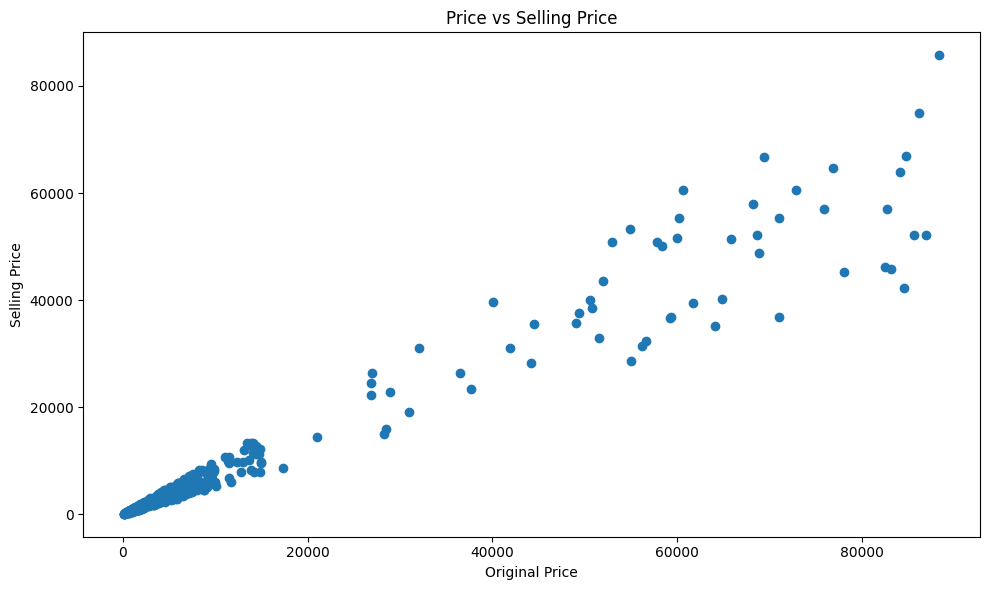

In [ ]:
# STEP 45 - PRICE VS SELLING PRICE

plt.figure(figsize=(10, 6))

plt.scatter(df["Price"], df["Selling_Price"])

plt.title("Price vs Selling Price")
plt.xlabel("Original Price")
plt.ylabel("Selling Price")

plt.tight_layout()
plt.show()

In [ ]:
# STEP 46 - CATEGORY WISE DISCOUNT ANALYSIS

category_discount = df.groupby("Category")["Discount_Percent"].agg(
    ["mean", "min", "max"]
).round(2)

print("--- CATEGORY WISE DISCOUNT ---")
category_discount

--- CATEGORY WISE DISCOUNT ---


,mean,min,max
Category,,,
Beauty,26.42,0,49
Books,24.90,1,50
Electronics,25.65,0,50
Fashion,25.55,0,50
Grocery,25.17,0,50
Home & Kitchen,23.43,0,49
Sports,23.63,0,50


In [ ]:
# STEP 47 - CATEGORY WISE AVERAGE REVIEW COUNT

category_avg_reviews = (
    df.groupby("Category")["Review_Count"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print("--- CATEGORY WISE AVERAGE REVIEW COUNT ---")
print(category_avg_reviews)

--- CATEGORY WISE AVERAGE REVIEW COUNT ---
Category
Fashion           2011.22
Grocery           1934.18
Home & Kitchen    1928.75
Sports            1805.59
Beauty            1756.10
Books             1729.03
Electronics       1706.85
Name: Review_Count, dtype: float64


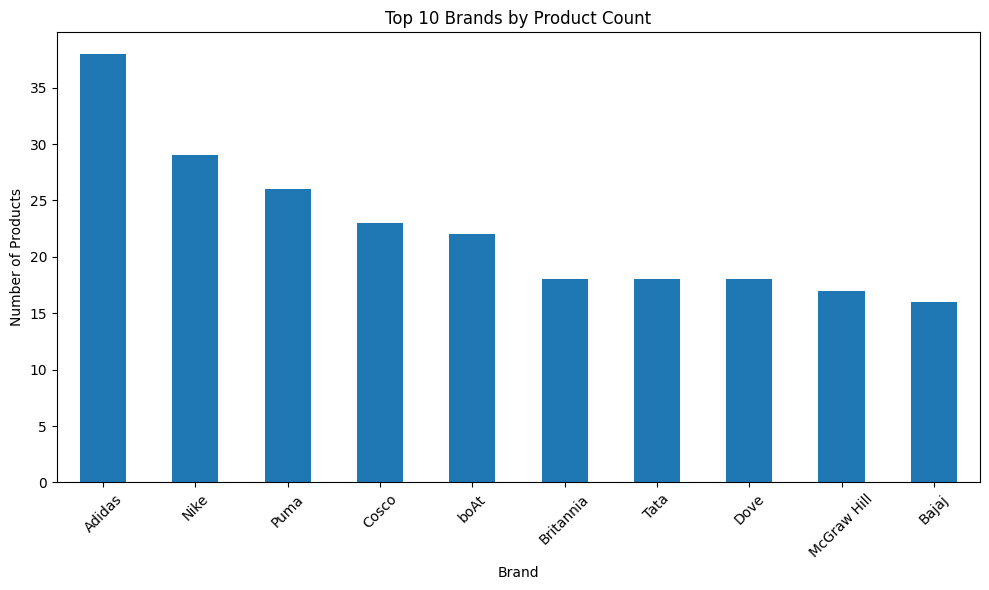

In [ ]:
# STEP 48 - TOP 10 BRANDS BY PRODUCT COUNT

brand_count = df["Brand"].value_counts().head(10)

plt.figure(figsize=(10, 6))

brand_count.plot(kind="bar")

plt.title("Top 10 Brands by Product Count")
plt.xlabel("Brand")
plt.ylabel("Number of Products")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# STEP 49 - OVERALL PROJECT SUMMARY

print("========== E-COMMERCE PROJECT SUMMARY ==========")

print("Total Products:", len(df))
print("Total Categories:", df["Category"].nunique())
print("Total Brands:", df["Brand"].nunique())

print("\n--- PRICE ---")
print("Average Price:", round(df["Price"].mean(), 2))
print("Average Selling Price:", round(df["Selling_Price"].mean(), 2))

print("\n--- RATING & REVIEWS ---")
print("Average Rating:", round(df["Rating"].mean(), 2))
print("Total Reviews:", df["Review_Count"].sum())

print("\n--- DISCOUNT ---")
print("Average Discount:", round(df["Discount_Percent"].mean(), 2))

print("\n--- STOCK ---")
print("Total Stock:", df["Stock"].sum())
print("Average Stock:", round(df["Stock"].mean(), 2))

print("\n--- TOP CATEGORIES ---")
print(
    "Most Products:",
    df["Category"].value_counts().idxmax()
)

print(
    "Highest Average Rating:",
    df.groupby("Category")["Rating"].mean().idxmax()
)

print(
    "Highest Sales Potential:",
    df.groupby("Category")["Sales_Potential"].sum().idxmax()
)

========== E-COMMERCE PROJECT SUMMARY ==========
Total Products: 500
Total Categories: 7
Total Brands: 32

--- PRICE ---
Average Price: 10059.75
Average Selling Price: 7470.07

--- RATING & REVIEWS ---
Average Rating: 3.89
Total Reviews: 918279

--- DISCOUNT ---
Average Discount: 24.95

--- STOCK ---
Total Stock: 128728
Average Stock: 257.46

--- TOP CATEGORIES ---
Most Products: Sports
Highest Average Rating: Electronics
Highest Sales Potential: Electronics


In [ ]:
# STEP 50 - SAVE FINAL DATASET

df.to_csv("ecommerce_products_final.csv", index=False)

print("===================================")
print("PROJECT COMPLETED SUCCESSFULLY!")
print("===================================")
print("Final Dataset: ecommerce_products_final.csv")
print("Total Rows:", len(df))
print("Total Columns:", len(df.columns))

PROJECT COMPLETED SUCCESSFULLY!
Final Dataset: ecommerce_products_final.csv
Total Rows: 500
Total Columns: 13


In [ ]:
# SQL STEP 1 - INSTALL DUCKDB

!pip install duckdb -q

import duckdb

print("DuckDB installed successfully!")

DuckDB installed successfully!


In [ ]:
# SQL STEP 2 - LOAD CSV INTO SQL TABLE

import duckdb

con = duckdb.connect()

con.execute("""
CREATE OR REPLACE TABLE products AS
SELECT *
FROM read_csv_auto('ecommerce_products.csv')
""")

print("Products table created successfully!")

Products table created successfully!


In [ ]:
con.execute("SELECT * FROM products LIMIT 5").df()

,Product_ID,Product_Name,Category,Sub_Category,Brand,Price,Discount_Percent,Rating,Review_Count,Stock,Selling_Price
0,P0001,Nike Running Shoes Essential,Sports,Running Shoes,Nike,4806,15,3.3,1621,456,4085.10
1,P0002,McGraw Hill Novel Premium,Books,Novel,McGraw Hill,280,1,3.0,10,119,277.20
2,P0003,Penguin Academic Book Max,Books,Academic Book,Penguin,964,45,4.2,851,301,530.20
3,P0004,Puma T-Shirt Essential,Fashion,T-Shirt,Puma,3862,21,3.4,1524,110,3050.98
4,P0005,Tata Dry Fruits Pro,Grocery,Dry Fruits,Tata,1656,6,3.6,1189,22,1556.64


In [ ]:
# SQL STEP 3 - TOTAL PRODUCTS

result = con.execute("""
SELECT COUNT(*) AS Total_Products
FROM products
""").df()

result

,Total_Products
0,500


In [ ]:
# SQL STEP 4 - CATEGORY WISE PRODUCT COUNT

result = con.execute("""
SELECT
    Category,
    COUNT(*) AS Product_Count
FROM products
GROUP BY Category
ORDER BY Product_Count DESC
""").df()

result

,Category,Product_Count
0,Sports,82
1,Beauty,73
2,Books,72
3,Grocery,71
4,Fashion,69
5,Electronics,68
6,Home & Kitchen,65


In [ ]:
# SQL STEP 5 - AVERAGE PRICE BY CATEGORY

result = con.execute("""
SELECT
    Category,
    ROUND(AVG(Price), 2) AS Average_Price
FROM products
GROUP BY Category
ORDER BY Average_Price DESC
""").df()

result

,Category,Average_Price
0,Electronics,50396.10
1,Home & Kitchen,8318.92
2,Sports,4994.91
3,Fashion,4370.33
4,Beauty,2138.60
5,Grocery,1400.31
6,Books,1326.85


In [ ]:
# SQL STEP 6 - AVERAGE RATING BY CATEGORY

result = con.execute("""
SELECT
    Category,
    ROUND(AVG(Rating), 2) AS Average_Rating
FROM products
GROUP BY Category
ORDER BY Average_Rating DESC
""").df()

result

,Category,Average_Rating
0,Electronics,4.05
1,Fashion,3.97
2,Grocery,3.89
3,Books,3.88
4,Beauty,3.88
5,Home & Kitchen,3.86
6,Sports,3.75


In [ ]:
# SQL STEP 7 - TOP 10 MOST EXPENSIVE PRODUCTS

result = con.execute("""
SELECT
    Product_Name,
    Category,
    Brand,
    Price,
    Selling_Price
FROM products
ORDER BY Price DESC
LIMIT 10
""").df()

result

,Product_Name,Category,Brand,Price,Selling_Price
0,Samsung Tablet Pro,Electronics,Samsung,88384,85732.48
1,HP Headphones Essential,Electronics,HP,86927,52156.20
2,Lenovo Smartphone Classic,Electronics,Lenovo,86144,74945.28
3,boAt Laptop Plus,Electronics,boAt,85603,52217.83
4,Lenovo Smartphone Classic,Electronics,Lenovo,84812,67001.48
5,HP Smartphone Premium,Electronics,HP,84548,42274.00
6,Apple Smartwatch Pro,Electronics,Apple,84118,63929.68
7,Lenovo Smartwatch Classic,Electronics,Lenovo,83188,45753.40
8,boAt Headphones Plus,Electronics,boAt,82724,57079.56
9,boAt Smartwatch Classic,Electronics,boAt,82491,46194.96


In [ ]:
# SQL STEP 8 - TOP 10 MOST REVIEWED PRODUCTS

result = con.execute("""
SELECT
    Product_Name,
    Category,
    Brand,
    Rating,
    Review_Count
FROM products
ORDER BY Review_Count DESC
LIMIT 10
""").df()

result

,Product_Name,Category,Brand,Rating,Review_Count
0,Nike Running Shoes Essential,Sports,Nike,3.9,5770
1,Maybelline Shampoo Pro,Beauty,Maybelline,3.9,5715
2,Adidas Jeans Pro,Fashion,Adidas,4.1,5544
3,Lakme Shampoo Max,Beauty,Lakme,4.5,5511
4,Dove Moisturizer Essential,Beauty,Dove,3.8,5425
5,Maybelline Sunscreen Plus,Beauty,Maybelline,3.2,5348
6,Puma Jeans Essential,Fashion,Puma,3.2,5074
7,Organic Tattva Snacks Pro,Grocery,Organic Tattva,4.4,5066
8,Yonex Dumbbells Max,Sports,Yonex,4.1,5023
9,Adidas Jeans Plus,Fashion,Adidas,4.0,4929


In [ ]:
# SQL STEP 9 - AVERAGE SELLING PRICE BY CATEGORY

result = con.execute("""
SELECT
    Category,
    ROUND(AVG(Selling_Price), 2) AS Average_Selling_Price
FROM products
GROUP BY Category
ORDER BY Average_Selling_Price DESC
""").df()

result

,Category,Average_Selling_Price
0,Electronics,37061.19
1,Home & Kitchen,6396.37
2,Sports,3819.68
3,Fashion,3240.68
4,Beauty,1584.36
5,Grocery,1051.26
6,Books,999.90


In [ ]:
# SQL STEP 10 - TOTAL REVIEWS BY CATEGORY

result = con.execute("""
SELECT
    Category,
    SUM(Review_Count) AS Total_Reviews
FROM products
GROUP BY Category
ORDER BY Total_Reviews DESC
""").df()

result

,Category,Total_Reviews
0,Sports,148058.0
1,Fashion,138774.0
2,Grocery,137327.0
3,Beauty,128195.0
4,Home & Kitchen,125369.0
5,Books,124490.0
6,Electronics,116066.0


In [ ]:
# SQL STEP 11 - TOP 10 PRODUCTS BY DISCOUNT

result = con.execute("""
SELECT
    Product_Name,
    Category,
    Brand,
    Price,
    Discount_Percent,
    Selling_Price
FROM products
ORDER BY Discount_Percent DESC
LIMIT 10
""").df()

result

,Product_Name,Category,Brand,Price,Discount_Percent,Selling_Price
0,Cosco Football Classic,Sports,Cosco,1779,50,889.50
1,boAt Smartphone Plus,Electronics,boAt,17305,50,8652.50
2,Oxford Programming Book Classic,Books,Oxford,754,50,377.00
3,HP Smartphone Premium,Electronics,HP,84548,50,42274.00
4,Allen Solly T-Shirt Max,Fashion,Allen Solly,4556,50,2278.00
5,Adidas Cricket Bat Pro,Sports,Adidas,5823,50,2911.50
6,Pearson Academic Book Classic,Books,Pearson,1244,50,622.00
7,Organic Tattva Tea Premium,Grocery,Organic Tattva,1248,50,624.00
8,Adidas Dumbbells Essential,Sports,Adidas,5613,49,2862.63
9,Bajaj Mixer Pro,Home & Kitchen,Bajaj,8817,49,4496.67


In [ ]:
# SQL STEP 12 - HIGH RATED PRODUCTS

result = con.execute("""
SELECT
    Product_Name,
    Category,
    Brand,
    Rating,
    Review_Count,
    Selling_Price
FROM products
WHERE Rating > 4.5
ORDER BY Rating DESC, Review_Count DESC
LIMIT 10
""").df()

result

,Product_Name,Category,Brand,Rating,Review_Count,Selling_Price
0,Allen Solly T-Shirt Max,Fashion,Allen Solly,5.0,3720,2278.00
1,Lenovo Smartwatch Pro,Electronics,Lenovo,5.0,3698,4383.70
2,Tata Tea Pro,Grocery,Tata,5.0,3576,179.52
3,HP Smartphone Premium,Electronics,HP,5.0,3235,60636.00
4,Apple Headphones Essential,Electronics,Apple,5.0,2335,38583.68
5,Adidas T-Shirt Pro,Fashion,Adidas,5.0,2294,2434.74
6,Apple Smartphone Classic,Electronics,Apple,5.0,2285,6043.62
7,Apple Smartwatch Essential,Electronics,Apple,5.0,1866,28300.80
8,Apple Smartwatch Pro,Electronics,Apple,5.0,1794,63929.68
9,Pigeon Vacuum Cleaner Classic,Home & Kitchen,Pigeon,5.0,715,8131.94


In [ ]:
# SQL STEP 13 - LOW STOCK PRODUCTS

result = con.execute("""
SELECT
    Product_Name,
    Category,
    Brand,
    Stock,
    Selling_Price
FROM products
WHERE Stock < 20
ORDER BY Stock ASC
LIMIT 10
""").df()

result

,Product_Name,Category,Brand,Stock,Selling_Price
0,HarperCollins Programming Book Classic,Books,HarperCollins,0,1247.52
1,Adidas Running Shoes Plus,Sports,Adidas,1,2045.55
2,Oxford Programming Book Classic,Books,Oxford,1,377.00
3,Maybelline Moisturizer Plus,Beauty,Maybelline,9,1863.94
4,Lenovo Headphones Premium,Electronics,Lenovo,10,56967.00
5,Cosco Dumbbells Classic,Sports,Cosco,14,9343.32
6,Nike Yoga Mat Essential,Sports,Nike,17,765.45
7,Britannia Dry Fruits Premium,Grocery,Britannia,18,838.20
8,Adidas Dumbbells Max,Sports,Adidas,18,810.79


In [ ]:
# SQL STEP 14 - BRAND WISE PRODUCT COUNT

result = con.execute("""
SELECT
    Brand,
    COUNT(*) AS Product_Count
FROM products
GROUP BY Brand
ORDER BY Product_Count DESC
LIMIT 10
""").df()

result

,Brand,Product_Count
0,Adidas,38
1,Nike,29
2,Puma,26
3,Cosco,23
4,boAt,22
5,Tata,18
6,Dove,18
7,Britannia,18
8,McGraw Hill,17
9,Bajaj,16


In [ ]:
# SQL STEP 15 - BRAND WISE AVERAGE RATING

result = con.execute("""
SELECT
    Brand,
    ROUND(AVG(Rating), 2) AS Average_Rating
FROM products
GROUP BY Brand
ORDER BY Average_Rating DESC
LIMIT 10
""").df()

result

,Brand,Average_Rating
0,Samsung,4.29
1,Oxford,4.13
2,Nivea,4.12
3,Apple,4.08
4,Adidas,4.06
5,Nike,4.05
6,Minimalist,4.04
7,Lenovo,4.02
8,Bajaj,4.02
9,HP,4.00


In [ ]:
# SQL STEP 16 - BRAND WISE TOTAL REVIEWS

result = con.execute("""
SELECT
    Brand,
    SUM(Review_Count) AS Total_Reviews
FROM products
GROUP BY Brand
ORDER BY Total_Reviews DESC
LIMIT 10
""").df()

result

,Brand,Total_Reviews
0,Adidas,69762.0
1,Nike,61954.0
2,Cosco,44272.0
3,Bajaj,42504.0
4,Puma,40400.0
5,Britannia,38909.0
6,Allen Solly,38358.0
7,boAt,36590.0
8,Organic Tattva,32957.0
9,McGraw Hill,32411.0


In [ ]:
# SQL STEP 17 - BRAND WISE AVERAGE SELLING PRICE

result = con.execute("""
SELECT
    Brand,
    ROUND(AVG(Selling_Price), 2) AS Average_Selling_Price
FROM products
GROUP BY Brand
ORDER BY Average_Selling_Price DESC
LIMIT 10
""").df()

result

,Brand,Average_Selling_Price
0,HP,46494.08
1,Lenovo,42311.25
2,Apple,36322.63
3,boAt,34018.42
4,Samsung,33080.43
5,Bajaj,7558.41
6,Havells,6270.05
7,Philips,6052.67
8,Prestige,5894.24
9,Pigeon,5731.16


In [ ]:
# SQL STEP 18 - BRAND WISE AVERAGE DISCOUNT

result = con.execute("""
SELECT
    Brand,
    ROUND(AVG(Discount_Percent), 2) AS Average_Discount
FROM products
GROUP BY Brand
ORDER BY Average_Discount DESC
LIMIT 10
""").df()

result

,Brand,Average_Discount
0,Aashirvaad,32.92
1,boAt,32.50
2,Allen Solly,32.20
3,Lakme,31.00
4,Dove,29.06
5,Nivea,28.92
6,Organic Tattva,28.15
7,Pearson,27.85
8,Oxford,27.81
9,Adidas,26.87


In [ ]:
# SQL STEP 19 - SUB-CATEGORY WISE PRODUCT COUNT

result = con.execute("""
SELECT
    Sub_Category,
    COUNT(*) AS Product_Count
FROM products
GROUP BY Sub_Category
ORDER BY Product_Count DESC
LIMIT 10
""").df()

result

,Sub_Category,Product_Count
0,Shampoo,22
1,Jeans,21
2,Dumbbells,20
3,Cricket Bat,20
4,T-Shirt,18
5,Self Help Book,17
6,Smartphone,17
7,Headphones,16
8,Vacuum Cleaner,16
9,Football,16


In [ ]:
# SQL STEP 20 - SUB-CATEGORY WISE AVERAGE RATING

result = con.execute("""
SELECT
    Sub_Category,
    ROUND(AVG(Rating), 2) AS Average_Rating
FROM products
GROUP BY Sub_Category
ORDER BY Average_Rating DESC
LIMIT 10
""").df()

result

,Sub_Category,Average_Rating
0,Smartwatch,4.42
1,Tablet,4.29
2,T-Shirt,4.13
3,Cookware Set,4.05
4,Jeans,4.05
5,Headphones,4.02
6,Coffee,3.99
7,Yoga Mat,3.99
8,Novel,3.99
9,Tea,3.97


In [ ]:
# SQL STEP 21 - SUB-CATEGORY WISE TOTAL REVIEWS

result = con.execute("""
SELECT
    Sub_Category,
    SUM(Review_Count) AS Total_Reviews
FROM products
GROUP BY Sub_Category
ORDER BY Total_Reviews DESC
LIMIT 10
""").df()

result

,Sub_Category,Total_Reviews
0,Jeans,53919.0
1,Shampoo,47944.0
2,Dumbbells,42655.0
3,Cricket Bat,37764.0
4,Vacuum Cleaner,37322.0
5,Smartphone,34929.0
6,Tea,34197.0
7,Programming Book,32948.0
8,T-Shirt,30325.0
9,Self Help Book,28806.0


In [ ]:
# SQL STEP 22 - SUB-CATEGORY WISE AVERAGE SELLING PRICE

result = con.execute("""
SELECT
    Sub_Category,
    ROUND(AVG(Selling_Price), 2) AS Average_Selling_Price
FROM products
GROUP BY Sub_Category
ORDER BY Average_Selling_Price DESC
LIMIT 10
""").df()

result

,Sub_Category,Average_Selling_Price
0,Laptop,40254.09
1,Tablet,38589.20
2,Smartphone,38510.15
3,Headphones,35848.75
4,Smartwatch,33454.05
5,Vacuum Cleaner,7569.56
6,Coffee Maker,7490.96
7,Air Fryer,6526.83
8,Cookware Set,5342.55
9,Mixer,5187.12


In [ ]:
# SQL STEP 23 - SUB-CATEGORY WISE AVERAGE DISCOUNT

result = con.execute("""
SELECT
    Sub_Category,
    ROUND(AVG(Discount_Percent), 2) AS Average_Discount
FROM products
GROUP BY Sub_Category
ORDER BY Average_Discount DESC
LIMIT 10
""").df()

result

,Sub_Category,Average_Discount
0,Sunscreen,32.89
1,Handbag,30.55
2,Dry Fruits,29.93
3,Football,29.38
4,Cookware Set,28.80
5,T-Shirt,27.94
6,Tea,27.80
7,Smartphone,27.35
8,Smartwatch,27.13
9,Mixer,26.92


In [ ]:
# SQL STEP 24 - BEST VALUE PRODUCTS

result = con.execute("""
SELECT
    Product_Name,
    Category,
    Brand,
    Rating,
    Discount_Percent,
    Selling_Price,
    ROUND(Rating * Discount_Percent, 2) AS Value_Score
FROM products
ORDER BY Value_Score DESC
LIMIT 10
""").df()

result

,Product_Name,Category,Brand,Rating,Discount_Percent,Selling_Price,Value_Score
0,Allen Solly T-Shirt Max,Fashion,Allen Solly,5.0,50,2278.00,250.0
1,Tata Tea Pro,Grocery,Tata,5.0,49,179.52,245.0
2,Oxford Programming Book Classic,Books,Oxford,4.8,50,377.00,240.0
3,Pigeon Air Fryer Max,Home & Kitchen,Pigeon,4.9,48,5223.92,235.2
4,Adidas Dumbbells Essential,Sports,Adidas,4.5,49,2862.63,220.5
5,Oxford Academic Book Pro,Books,Oxford,4.5,49,653.31,220.5
6,Adidas Sneakers Plus,Fashion,Adidas,4.9,45,2900.70,220.5
7,Puma Football Premium,Sports,Puma,4.7,46,536.22,216.2
8,boAt Smartwatch Max,Electronics,boAt,4.7,45,7835.30,211.5
9,Aashirvaad Dry Fruits Classic,Grocery,Aashirvaad,4.5,47,328.07,211.5


In [ ]:
# SQL STEP 25 - SALES POTENTIAL

result = con.execute("""
SELECT
    Product_Name,
    Category,
    Brand,
    Selling_Price,
    Stock,
    ROUND(Selling_Price * Stock, 2) AS Sales_Potential
FROM products
ORDER BY Sales_Potential DESC
LIMIT 10
""").df()

result

,Product_Name,Category,Brand,Selling_Price,Stock,Sales_Potential
0,Apple Headphones Classic,Electronics,Apple,66683.52,499,33275076.48
1,Lenovo Smartphone Classic,Electronics,Lenovo,67001.48,488,32696722.24
2,Apple Smartwatch Pro,Electronics,Apple,63929.68,403,25763661.04
3,boAt Laptop Premium,Electronics,boAt,48896.99,476,23274967.24
4,Lenovo Laptop Plus,Electronics,Lenovo,50884.80,434,22084003.20
5,HP Tablet Premium,Electronics,HP,51587.96,423,21821707.08
6,Samsung Laptop Plus,Electronics,Samsung,51374.70,400,20549880.00
7,HP Smartphone Classic,Electronics,HP,40216.92,491,19746507.72
8,boAt Smartphone Plus,Electronics,boAt,64595.16,305,19701523.80
9,Lenovo Smartwatch Premium,Electronics,Lenovo,60482.10,319,19293789.90


In [ ]:
# SQL STEP 26 - CATEGORY WISE SALES POTENTIAL

result = con.execute("""
SELECT
    Category,
    ROUND(SUM(Selling_Price * Stock), 2) AS Total_Sales_Potential
FROM products
GROUP BY Category
ORDER BY Total_Sales_Potential DESC
""").df()

result

,Category,Total_Sales_Potential
0,Electronics,7.010816e+08
1,Home & Kitchen,1.076096e+08
2,Sports,7.528775e+07
3,Fashion,5.963399e+07
4,Beauty,2.986916e+07
5,Books,1.826680e+07
6,Grocery,1.715812e+07


In [ ]:
# SQL STEP 27 - LOW STOCK PRODUCTS

result = con.execute("""
SELECT
    Product_Name,
    Category,
    Brand,
    Stock,
    Selling_Price
FROM products
WHERE Stock < 20
ORDER BY Stock ASC
LIMIT 10
""").df()

result

,Product_Name,Category,Brand,Stock,Selling_Price
0,HarperCollins Programming Book Classic,Books,HarperCollins,0,1247.52
1,Adidas Running Shoes Plus,Sports,Adidas,1,2045.55
2,Oxford Programming Book Classic,Books,Oxford,1,377.00
3,Maybelline Moisturizer Plus,Beauty,Maybelline,9,1863.94
4,Lenovo Headphones Premium,Electronics,Lenovo,10,56967.00
5,Cosco Dumbbells Classic,Sports,Cosco,14,9343.32
6,Nike Yoga Mat Essential,Sports,Nike,17,765.45
7,Britannia Dry Fruits Premium,Grocery,Britannia,18,838.20
8,Adidas Dumbbells Max,Sports,Adidas,18,810.79


In [ ]:
# SQL STEP 28 - HIGH STOCK PRODUCTS

result = con.execute("""
SELECT
    Product_Name,
    Category,
    Brand,
    Stock,
    Selling_Price
FROM products
ORDER BY Stock DESC
LIMIT 10
""").df()

result

,Product_Name,Category,Brand,Stock,Selling_Price
0,Apple Headphones Classic,Electronics,Apple,499,66683.52
1,Lakme Shampoo Max,Beauty,Lakme,498,2105.01
2,Apple Smartwatch Essential,Electronics,Apple,498,28300.80
3,Nivea Shampoo Max,Beauty,Nivea,496,1161.00
4,Nestle Coffee Plus,Grocery,Nestle,495,1826.85
5,Philips Air Fryer Essential,Home & Kitchen,Philips,495,3226.21
6,Maybelline Shampoo Pro,Beauty,Maybelline,494,388.50
7,McGraw Hill Programming Book Pro,Books,McGraw Hill,493,1850.85
8,Aashirvaad Organic Rice Classic,Grocery,Aashirvaad,493,876.06
9,Minimalist Shampoo Plus,Beauty,Minimalist,492,325.44


In [ ]:
# SQL STEP 29 - PRICE VS SELLING PRICE

result = con.execute("""
SELECT
    Product_Name,
    Category,
    Price,
    Selling_Price,
    ROUND(Price - Selling_Price, 2) AS Discount_Amount
FROM products
ORDER BY Discount_Amount DESC
LIMIT 10
""").df()

result

,Product_Name,Category,Price,Selling_Price,Discount_Amount
0,HP Smartphone Premium,Electronics,84548,42274.00,42274.00
1,Lenovo Smartwatch Classic,Electronics,83188,45753.40,37434.60
2,boAt Smartwatch Classic,Electronics,82491,46194.96,36296.04
3,HP Headphones Essential,Electronics,86927,52156.20,34770.80
4,boAt Laptop Pro,Electronics,71036,36938.72,34097.28
5,boAt Laptop Plus,Electronics,85603,52217.83,33385.17
6,boAt Laptop Essential,Electronics,78104,45300.32,32803.68
7,Lenovo Headphones Max,Electronics,64073,35240.15,28832.85
8,boAt Smartphone Max,Electronics,55062,28632.24,26429.76
9,boAt Headphones Plus,Electronics,82724,57079.56,25644.44


In [ ]:
# SQL STEP 30 - CATEGORY WISE DISCOUNT

result = con.execute("""
SELECT
    Category,
    ROUND(AVG(Discount_Percent), 2) AS Average_Discount,
    MIN(Discount_Percent) AS Minimum_Discount,
    MAX(Discount_Percent) AS Maximum_Discount
FROM products
GROUP BY Category
ORDER BY Average_Discount DESC
""").df()

result

,Category,Average_Discount,Minimum_Discount,Maximum_Discount
0,Beauty,26.42,0,49
1,Electronics,25.65,0,50
2,Fashion,25.55,0,50
3,Grocery,25.17,0,50
4,Books,24.90,1,50
5,Sports,23.63,0,50
6,Home & Kitchen,23.43,0,49


In [ ]:
# SQL STEP 31 - CATEGORY WISE AVERAGE REVIEW COUNT

result = con.execute("""
SELECT
    Category,
    ROUND(AVG(Review_Count), 2) AS Average_Review_Count
FROM products
GROUP BY Category
ORDER BY Average_Review_Count DESC
""").df()

result

,Category,Average_Review_Count
0,Fashion,2011.22
1,Grocery,1934.18
2,Home & Kitchen,1928.75
3,Sports,1805.59
4,Beauty,1756.10
5,Books,1729.03
6,Electronics,1706.85


In [ ]:
# SQL STEP 32 - BRAND WISE PRODUCT COUNT

result = con.execute("""
SELECT
    Brand,
    COUNT(*) AS Product_Count
FROM products
GROUP BY Brand
ORDER BY Product_Count DESC
LIMIT 10
""").df()

result

,Brand,Product_Count
0,Adidas,38
1,Nike,29
2,Puma,26
3,Cosco,23
4,boAt,22
5,Tata,18
6,Dove,18
7,Britannia,18
8,McGraw Hill,17
9,Bajaj,16


In [ ]:
# SQL STEP 33 - BRAND WISE AVERAGE RATING

result = con.execute("""
SELECT
    Brand,
    ROUND(AVG(Rating), 2) AS Average_Rating
FROM products
GROUP BY Brand
ORDER BY Average_Rating DESC
LIMIT 10
""").df()

result

,Brand,Average_Rating
0,Samsung,4.29
1,Oxford,4.13
2,Nivea,4.12
3,Apple,4.08
4,Adidas,4.06
5,Nike,4.05
6,Minimalist,4.04
7,Bajaj,4.02
8,Lenovo,4.02
9,HP,4.00


In [ ]:
# SQL STEP 34 - BRAND WISE TOTAL REVIEWS

result = con.execute("""
SELECT
    Brand,
    SUM(Review_Count) AS Total_Reviews
FROM products
GROUP BY Brand
ORDER BY Total_Reviews DESC
LIMIT 10
""").df()

result

,Brand,Total_Reviews
0,Adidas,69762.0
1,Nike,61954.0
2,Cosco,44272.0
3,Bajaj,42504.0
4,Puma,40400.0
5,Britannia,38909.0
6,Allen Solly,38358.0
7,boAt,36590.0
8,Organic Tattva,32957.0
9,McGraw Hill,32411.0


In [ ]:
# SQL STEP 35 - BRAND WISE AVERAGE SELLING PRICE

result = con.execute("""
SELECT
    Brand,
    ROUND(AVG(Selling_Price), 2) AS Average_Selling_Price
FROM products
GROUP BY Brand
ORDER BY Average_Selling_Price DESC
LIMIT 10
""").df()

result

,Brand,Average_Selling_Price
0,HP,46494.08
1,Lenovo,42311.25
2,Apple,36322.63
3,boAt,34018.42
4,Samsung,33080.43
5,Bajaj,7558.41
6,Havells,6270.05
7,Philips,6052.67
8,Prestige,5894.24
9,Pigeon,5731.16


In [ ]:
# SQL STEP 36 - BRAND WISE AVERAGE DISCOUNT

result = con.execute("""
SELECT
    Brand,
    ROUND(AVG(Discount_Percent), 2) AS Average_Discount
FROM products
GROUP BY Brand
ORDER BY Average_Discount DESC
LIMIT 10
""").df()

result

,Brand,Average_Discount
0,Aashirvaad,32.92
1,boAt,32.50
2,Allen Solly,32.20
3,Lakme,31.00
4,Dove,29.06
5,Nivea,28.92
6,Organic Tattva,28.15
7,Pearson,27.85
8,Oxford,27.81
9,Adidas,26.87


In [ ]:
# SQL STEP 37 - OVERALL PROJECT SUMMARY

result = con.execute("""
SELECT
    COUNT(*) AS Total_Products,
    COUNT(DISTINCT Category) AS Total_Categories,
    COUNT(DISTINCT Brand) AS Total_Brands,
    ROUND(AVG(Price), 2) AS Average_Price,
    ROUND(AVG(Selling_Price), 2) AS Average_Selling_Price,
    ROUND(AVG(Rating), 2) AS Average_Rating,
    SUM(Review_Count) AS Total_Reviews,
    ROUND(AVG(Discount_Percent), 2) AS Average_Discount,
    SUM(Stock) AS Total_Stock,
    ROUND(AVG(Stock), 2) AS Average_Stock
FROM products
""").df()

result

,Total_Products,Total_Categories,Total_Brands,Average_Price,Average_Selling_Price,Average_Rating,Total_Reviews,Average_Discount,Total_Stock,Average_Stock
0,500,7,32,10059.75,7470.07,3.89,918279.0,24.95,128728.0,257.46


In [ ]:
# SQL STEP 38 - HIGHEST SALES POTENTIAL CATEGORY

result = con.execute("""
SELECT
    Category,
    ROUND(SUM(Selling_Price * Stock), 2) AS Total_Sales_Potential
FROM products
GROUP BY Category
ORDER BY Total_Sales_Potential DESC
LIMIT 1
""").df()

result

,Category,Total_Sales_Potential
0,Electronics,7.010816e+08


In [ ]:
# SQL STEP 39 - HIGHEST RATED CATEGORY

result = con.execute("""
SELECT
    Category,
    ROUND(AVG(Rating), 2) AS Average_Rating
FROM products
GROUP BY Category
ORDER BY Average_Rating DESC
LIMIT 1
""").df()

result

,Category,Average_Rating
0,Electronics,4.05


In [ ]:
# SQL STEP 40 - HIGHEST AVERAGE PRICE CATEGORY

result = con.execute("""
SELECT
    Category,
    ROUND(AVG(Price), 2) AS Average_Price
FROM products
GROUP BY Category
ORDER BY Average_Price DESC
LIMIT 1
""").df()

result

,Category,Average_Price
0,Electronics,50396.1


In [ ]:
# SQL STEP 41 - LOWEST STOCK PRODUCTS

result = con.execute("""
SELECT
    Product_Name,
    Category,
    Brand,
    Stock,
    Selling_Price
FROM products
ORDER BY Stock ASC
LIMIT 10
""").df()

result

,Product_Name,Category,Brand,Stock,Selling_Price
0,HarperCollins Programming Book Classic,Books,HarperCollins,0,1247.52
1,Adidas Running Shoes Plus,Sports,Adidas,1,2045.55
2,Oxford Programming Book Classic,Books,Oxford,1,377.00
3,Maybelline Moisturizer Plus,Beauty,Maybelline,9,1863.94
4,Lenovo Headphones Premium,Electronics,Lenovo,10,56967.00
5,Cosco Dumbbells Classic,Sports,Cosco,14,9343.32
6,Nike Yoga Mat Essential,Sports,Nike,17,765.45
7,Britannia Dry Fruits Premium,Grocery,Britannia,18,838.20
8,Adidas Dumbbells Max,Sports,Adidas,18,810.79
9,Tata Coffee Max,Grocery,Tata,20,376.00


In [ ]:
# SQL STEP 42 - HIGHEST DISCOUNT CATEGORY

result = con.execute("""
SELECT
    Category,
    ROUND(AVG(Discount_Percent), 2) AS Average_Discount
FROM products
GROUP BY Category
ORDER BY Average_Discount DESC
LIMIT 1
""").df()

result

,Category,Average_Discount
0,Beauty,26.42


In [ ]:
# SQL STEP 43 - HIGHEST RATED PRODUCTS

result = con.execute("""
SELECT
    Product_Name,
    Category,
    Brand,
    Rating,
    Review_Count,
    Selling_Price
FROM products
ORDER BY Rating DESC, Review_Count DESC
LIMIT 10
""").df()

result

,Product_Name,Category,Brand,Rating,Review_Count,Selling_Price
0,Allen Solly T-Shirt Max,Fashion,Allen Solly,5.0,3720,2278.00
1,Lenovo Smartwatch Pro,Electronics,Lenovo,5.0,3698,4383.70
2,Tata Tea Pro,Grocery,Tata,5.0,3576,179.52
3,HP Smartphone Premium,Electronics,HP,5.0,3235,60636.00
4,Apple Headphones Essential,Electronics,Apple,5.0,2335,38583.68
5,Adidas T-Shirt Pro,Fashion,Adidas,5.0,2294,2434.74
6,Apple Smartphone Classic,Electronics,Apple,5.0,2285,6043.62
7,Apple Smartwatch Essential,Electronics,Apple,5.0,1866,28300.80
8,Apple Smartwatch Pro,Electronics,Apple,5.0,1794,63929.68
9,Pigeon Vacuum Cleaner Classic,Home & Kitchen,Pigeon,5.0,715,8131.94


In [ ]:
# SQL STEP 44 - HIGHEST REVIEW COUNT PRODUCTS

result = con.execute("""
SELECT
    Product_Name,
    Category,
    Brand,
    Rating,
    Review_Count,
    Selling_Price
FROM products
ORDER BY Review_Count DESC
LIMIT 10
""").df()

result

,Product_Name,Category,Brand,Rating,Review_Count,Selling_Price
0,Nike Running Shoes Essential,Sports,Nike,3.9,5770,5355.35
1,Maybelline Shampoo Pro,Beauty,Maybelline,3.9,5715,388.50
2,Adidas Jeans Pro,Fashion,Adidas,4.1,5544,7549.00
3,Lakme Shampoo Max,Beauty,Lakme,4.5,5511,2105.01
4,Dove Moisturizer Essential,Beauty,Dove,3.8,5425,1789.92
5,Maybelline Sunscreen Plus,Beauty,Maybelline,3.2,5348,794.75
6,Puma Jeans Essential,Fashion,Puma,3.2,5074,3365.13
7,Organic Tattva Snacks Pro,Grocery,Organic Tattva,4.4,5066,2005.74
8,Yonex Dumbbells Max,Sports,Yonex,4.1,5023,738.70
9,Adidas Jeans Plus,Fashion,Adidas,4.0,4929,6140.16


In [ ]:
# SQL STEP 45 - MOST EXPENSIVE PRODUCT

result = con.execute("""
SELECT
    Product_Name,
    Category,
    Brand,
    Price,
    Selling_Price,
    Discount_Percent
FROM products
ORDER BY Price DESC
LIMIT 1
""").df()

result

,Product_Name,Category,Brand,Price,Selling_Price,Discount_Percent
0,Samsung Tablet Pro,Electronics,Samsung,88384,85732.48,3


In [ ]:
# SQL STEP 46 - LOWEST AVERAGE PRICE CATEGORY

result = con.execute("""
SELECT
    Category,
    ROUND(AVG(Price), 2) AS Average_Price
FROM products
GROUP BY Category
ORDER BY Average_Price ASC
LIMIT 1
""").df()

result

,Category,Average_Price
0,Books,1326.85


In [ ]:
# SQL STEP 47 - LOWEST RATED CATEGORY

result = con.execute("""
SELECT
    Category,
    ROUND(AVG(Rating), 2) AS Average_Rating
FROM products
GROUP BY Category
ORDER BY Average_Rating ASC
LIMIT 1
""").df()

result

,Category,Average_Rating
0,Sports,3.75


In [ ]:
# SQL STEP 48 - HIGHEST REVIEW COUNT CATEGORY

result = con.execute("""
SELECT
    Category,
    SUM(Review_Count) AS Total_Reviews
FROM products
GROUP BY Category
ORDER BY Total_Reviews DESC
LIMIT 1
""").df()

result

,Category,Total_Reviews
0,Sports,148058.0


In [ ]:
# SQL STEP 49 - LOWEST SELLING PRICE PRODUCT

result = con.execute("""
SELECT
    Product_Name,
    Category,
    Brand,
    Price,
    Selling_Price,
    Discount_Percent
FROM products
ORDER BY Selling_Price ASC
LIMIT 1
""").df()

result

,Product_Name,Category,Brand,Price,Selling_Price,Discount_Percent
0,Nestle Snacks Max,Grocery,Nestle,121,114.95,5


In [ ]:
# SQL STEP 50 - SQL PROJECT COMPLETION SUMMARY

result = con.execute("""
SELECT
    COUNT(*) AS Total_Products,
    COUNT(DISTINCT Category) AS Total_Categories,
    COUNT(DISTINCT Brand) AS Total_Brands,
    ROUND(AVG(Price), 2) AS Average_Price,
    ROUND(AVG(Selling_Price), 2) AS Average_Selling_Price,
    ROUND(AVG(Rating), 2) AS Average_Rating,
    SUM(Review_Count) AS Total_Reviews,
    ROUND(AVG(Discount_Percent), 2) AS Average_Discount,
    SUM(Stock) AS Total_Stock
FROM products
""").df()

result

,Total_Products,Total_Categories,Total_Brands,Average_Price,Average_Selling_Price,Average_Rating,Total_Reviews,Average_Discount,Total_Stock
0,500,7,32,10059.75,7470.07,3.89,918279.0,24.95,128728.0


In [ ]:
# EXCEL STEP 1 - EXPORT DATA TO EXCEL

result = con.execute("""
SELECT *
FROM products
""").df()

result.to_excel("ecommerce_products_analysis.xlsx", index=False)

print("Excel file created successfully!")
print("File Name: ecommerce_products_analysis.xlsx")

Excel file created successfully!
File Name: ecommerce_products_analysis.xlsx


In [ ]:
# EXCEL STEP 2 - LOAD EXCEL FILE

import pandas as pd

excel_df = pd.read_excel("ecommerce_products_analysis.xlsx")

print("Excel file loaded successfully!")
print("Rows:", excel_df.shape[0])
print("Columns:", excel_df.shape[1])

excel_df.head()

Excel file loaded successfully!
Rows: 500
Columns: 11


,Product_ID,Product_Name,Category,Sub_Category,Brand,Price,Discount_Percent,Rating,Review_Count,Stock,Selling_Price
0,P0001,Nike Running Shoes Essential,Sports,Running Shoes,Nike,4806,15,3.3,1621,456,4085.10
1,P0002,McGraw Hill Novel Premium,Books,Novel,McGraw Hill,280,1,3.0,10,119,277.20
2,P0003,Penguin Academic Book Max,Books,Academic Book,Penguin,964,45,4.2,851,301,530.20
3,P0004,Puma T-Shirt Essential,Fashion,T-Shirt,Puma,3862,21,3.4,1524,110,3050.98
4,P0005,Tata Dry Fruits Pro,Grocery,Dry Fruits,Tata,1656,6,3.6,1189,22,1556.64


In [ ]:
# EXCEL STEP 3 - DATA INSPECTION

print("Dataset Information:")
print(excel_df.info())

print("\nMissing Values:")
print(excel_df.isnull().sum())

print("\nDuplicate Rows:")
print(excel_df.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product_ID        500 non-null    object 
 1   Product_Name      500 non-null    object 
 2   Category          500 non-null    object 
 3   Sub_Category      500 non-null    object 
 4   Brand             500 non-null    object 
 5   Price             500 non-null    int64  
 6   Discount_Percent  500 non-null    int64  
 7   Rating            500 non-null    float64
 8   Review_Count      500 non-null    int64  
 9   Stock             500 non-null    int64  
 10  Selling_Price     500 non-null    float64
dtypes: float64(2), int64(4), object(5)
memory usage: 43.1+ KB
None

Missing Values:
Product_ID          0
Product_Name        0
Category            0
Sub_Category        0
Brand               0
Price               0
Discount_Percent    0
Rating              0
Re

In [ ]:
# EXCEL STEP 4 - STATISTICAL SUMMARY

print("--- NUMERICAL SUMMARY ---")

excel_df.describe()

--- NUMERICAL SUMMARY ---


,Price,Discount_Percent,Rating,Review_Count,Stock,Selling_Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,10059.748000,24.954000,3.894200,1836.558000,257.456000,7470.073180
std,18701.601971,14.919822,0.654923,1327.372582,143.967696,13981.934419
min,121.000000,0.000000,2.800000,10.000000,0.000000,114.950000
25%,1445.750000,13.000000,3.300000,800.750000,128.750000,1051.717500
50%,2954.000000,25.000000,3.900000,1773.000000,254.000000,2182.465000
75%,7307.000000,38.000000,4.500000,2657.000000,388.250000,5653.760000
max,88384.000000,50.000000,5.000000,5770.000000,499.000000,85732.480000


In [ ]:
# EXCEL STEP 5 - CATEGORY WISE PRODUCT COUNT

result = excel_df.groupby("Category").size().sort_values(ascending=False)

print("--- PRODUCT COUNT BY CATEGORY ---")
result

--- PRODUCT COUNT BY CATEGORY ---


,0
Category,
Sports,82
Beauty,73
Books,72
Grocery,71
Fashion,69
Electronics,68
Home & Kitchen,65


In [ ]:
# EXCEL STEP 6 - CATEGORY WISE AVERAGE PRICE

result = excel_df.groupby("Category")["Price"].mean().sort_values(ascending=False).round(2)

print("--- CATEGORY WISE AVERAGE PRICE ---")
result

--- CATEGORY WISE AVERAGE PRICE ---


,Price
Category,
Electronics,50396.10
Home & Kitchen,8318.92
Sports,4994.91
Fashion,4370.33
Beauty,2138.60
Grocery,1400.31
Books,1326.85


In [ ]:
# EXCEL STEP 7 - CATEGORY WISE AVERAGE RATING

result = excel_df.groupby("Category")["Rating"].mean().sort_values(ascending=False).round(2)

print("--- CATEGORY WISE AVERAGE RATING ---")
result

--- CATEGORY WISE AVERAGE RATING ---


,Rating
Category,
Electronics,4.05
Fashion,3.97
Grocery,3.89
Books,3.88
Beauty,3.88
Home & Kitchen,3.86
Sports,3.75


In [ ]:
# EXCEL STEP 8 - CATEGORY WISE TOTAL REVIEWS

result = excel_df.groupby("Category")["Review_Count"].sum().sort_values(ascending=False)

print("--- CATEGORY WISE TOTAL REVIEWS ---")
result

--- CATEGORY WISE TOTAL REVIEWS ---


,Review_Count
Category,
Sports,148058
Fashion,138774
Grocery,137327
Beauty,128195
Home & Kitchen,125369
Books,124490
Electronics,116066


In [ ]:
# EXCEL STEP 9 - TOP 10 MOST REVIEWED PRODUCTS

result = excel_df.sort_values(
    by="Review_Count",
    ascending=False
).head(10)

print("--- TOP 10 MOST REVIEWED PRODUCTS ---")
result[[
    "Product_Name",
    "Category",
    "Brand",
    "Rating",
    "Review_Count"
]]

--- TOP 10 MOST REVIEWED PRODUCTS ---


,Product_Name,Category,Brand,Rating,Review_Count
225,Nike Running Shoes Essential,Sports,Nike,3.9,5770
249,Maybelline Shampoo Pro,Beauty,Maybelline,3.9,5715
97,Adidas Jeans Pro,Fashion,Adidas,4.1,5544
137,Lakme Shampoo Max,Beauty,Lakme,4.5,5511
201,Dove Moisturizer Essential,Beauty,Dove,3.8,5425
495,Maybelline Sunscreen Plus,Beauty,Maybelline,3.2,5348
314,Puma Jeans Essential,Fashion,Puma,3.2,5074
78,Organic Tattva Snacks Pro,Grocery,Organic Tattva,4.4,5066
444,Yonex Dumbbells Max,Sports,Yonex,4.1,5023
451,Adidas Jeans Plus,Fashion,Adidas,4.0,4929


In [ ]:
# EXCEL STEP 10 - TOP 10 MOST EXPENSIVE PRODUCTS

result = excel_df.sort_values(
    by="Price",
    ascending=False
).head(10)

print("--- TOP 10 MOST EXPENSIVE PRODUCTS ---")
result[[
    "Product_Name",
    "Category",
    "Brand",
    "Price",
    "Selling_Price"
]]

--- TOP 10 MOST EXPENSIVE PRODUCTS ---


,Product_Name,Category,Brand,Price,Selling_Price
315,Samsung Tablet Pro,Electronics,Samsung,88384,85732.48
215,HP Headphones Essential,Electronics,HP,86927,52156.20
242,Lenovo Smartphone Classic,Electronics,Lenovo,86144,74945.28
347,boAt Laptop Plus,Electronics,boAt,85603,52217.83
16,Lenovo Smartphone Classic,Electronics,Lenovo,84812,67001.48
210,HP Smartphone Premium,Electronics,HP,84548,42274.00
214,Apple Smartwatch Pro,Electronics,Apple,84118,63929.68
396,Lenovo Smartwatch Classic,Electronics,Lenovo,83188,45753.40
338,boAt Headphones Plus,Electronics,boAt,82724,57079.56
127,boAt Smartwatch Classic,Electronics,boAt,82491,46194.96


In [ ]:
# EXCEL STEP 11 - CATEGORY WISE AVERAGE SELLING PRICE

result = excel_df.groupby("Category")["Selling_Price"].mean().sort_values(
    ascending=False
).round(2)

print("--- CATEGORY WISE AVERAGE SELLING PRICE ---")
result

--- CATEGORY WISE AVERAGE SELLING PRICE ---


,Selling_Price
Category,
Electronics,37061.19
Home & Kitchen,6396.37
Sports,3819.68
Fashion,3240.68
Beauty,1584.36
Grocery,1051.26
Books,999.90


In [ ]:
# EXCEL STEP 12 - TOP 10 HIGHEST DISCOUNT PRODUCTS

result = excel_df.sort_values(
    by="Discount_Percent",
    ascending=False
).head(10)

print("--- TOP 10 HIGHEST DISCOUNT PRODUCTS ---")
result[[
    "Product_Name",
    "Category",
    "Brand",
    "Price",
    "Discount_Percent",
    "Selling_Price"
]]

--- TOP 10 HIGHEST DISCOUNT PRODUCTS ---


,Product_Name,Category,Brand,Price,Discount_Percent,Selling_Price
342,Organic Tattva Tea Premium,Grocery,Organic Tattva,1248,50,624.00
210,HP Smartphone Premium,Electronics,HP,84548,50,42274.00
152,boAt Smartphone Plus,Electronics,boAt,17305,50,8652.50
153,Oxford Programming Book Classic,Books,Oxford,754,50,377.00
143,Cosco Football Classic,Sports,Cosco,1779,50,889.50
278,Adidas Cricket Bat Pro,Sports,Adidas,5823,50,2911.50
213,Allen Solly T-Shirt Max,Fashion,Allen Solly,4556,50,2278.00
320,Pearson Academic Book Classic,Books,Pearson,1244,50,622.00
433,Adidas T-Shirt Max,Fashion,Adidas,3328,49,1697.28
209,Cosco Dumbbells Premium,Sports,Cosco,2121,49,1081.71


In [ ]:
# EXCEL STEP 13 - TOP 10 HIGHEST SELLING PRICE PRODUCTS

result = excel_df.sort_values(
    by="Selling_Price",
    ascending=False
).head(10)

print("--- TOP 10 HIGHEST SELLING PRICE PRODUCTS ---")
result[[
    "Product_Name",
    "Category",
    "Brand",
    "Selling_Price",
    "Rating",
    "Review_Count"
]]

--- TOP 10 HIGHEST SELLING PRICE PRODUCTS ---


,Product_Name,Category,Brand,Selling_Price,Rating,Review_Count
315,Samsung Tablet Pro,Electronics,Samsung,85732.48,4.5,10
242,Lenovo Smartphone Classic,Electronics,Lenovo,74945.28,4.5,69
16,Lenovo Smartphone Classic,Electronics,Lenovo,67001.48,3.0,387
403,Apple Headphones Classic,Electronics,Apple,66683.52,3.4,4699
53,boAt Smartphone Plus,Electronics,boAt,64595.16,2.9,10
214,Apple Smartwatch Pro,Electronics,Apple,63929.68,5.0,1794
381,HP Smartphone Premium,Electronics,HP,60636.00,5.0,3235
253,Lenovo Smartwatch Premium,Electronics,Lenovo,60482.10,4.6,1296
25,boAt Smartphone Pro,Electronics,boAt,57962.35,3.4,2652
338,boAt Headphones Plus,Electronics,boAt,57079.56,4.1,2023


In [ ]:
# EXCEL STEP 14 - STOCK ANALYSIS

print("--- STOCK ANALYSIS ---")
print("Average Stock:", round(excel_df["Stock"].mean(), 2))
print("Minimum Stock:", excel_df["Stock"].min())
print("Maximum Stock:", excel_df["Stock"].max())

print("\n--- TOP 10 HIGH STOCK PRODUCTS ---")

result = excel_df.sort_values(
    by="Stock",
    ascending=False
).head(10)

result[[
    "Product_Name",
    "Category",
    "Brand",
    "Stock",
    "Selling_Price"
]]

--- STOCK ANALYSIS ---
Average Stock: 257.46
Minimum Stock: 0
Maximum Stock: 499

--- TOP 10 HIGH STOCK PRODUCTS ---


,Product_Name,Category,Brand,Stock,Selling_Price
403,Apple Headphones Classic,Electronics,Apple,499,66683.52
137,Lakme Shampoo Max,Beauty,Lakme,498,2105.01
323,Apple Smartwatch Essential,Electronics,Apple,498,28300.80
111,Nivea Shampoo Max,Beauty,Nivea,496,1161.00
480,Philips Air Fryer Essential,Home & Kitchen,Philips,495,3226.21
231,Nestle Coffee Plus,Grocery,Nestle,495,1826.85
249,Maybelline Shampoo Pro,Beauty,Maybelline,494,388.50
340,Aashirvaad Organic Rice Classic,Grocery,Aashirvaad,493,876.06
157,McGraw Hill Programming Book Pro,Books,McGraw Hill,493,1850.85
134,Minimalist Shampoo Plus,Beauty,Minimalist,492,325.44


In [ ]:
# EXCEL STEP 15 - CATEGORY WISE STOCK ANALYSIS

result = excel_df.groupby("Category")["Stock"].agg(
    Average_Stock="mean",
    Minimum_Stock="min",
    Maximum_Stock="max"
).round(2)

print("--- CATEGORY WISE STOCK ANALYSIS ---")
result

--- CATEGORY WISE STOCK ANALYSIS ---


,Average_Stock,Minimum_Stock,Maximum_Stock
Category,,,
Beauty,272.45,9,498
Books,252.06,0,493
Electronics,289.37,10,499
Fashion,265.28,45,491
Grocery,245.41,18,495
Home & Kitchen,256.00,22,495
Sports,227.39,1,476


In [ ]:
# EXCEL STEP 16 - RATING & REVIEW ANALYSIS

print("--- RATING & REVIEW ANALYSIS ---")
print("Average Rating:", round(excel_df["Rating"].mean(), 2))
print("Highest Rating:", excel_df["Rating"].max())
print("Lowest Rating:", excel_df["Rating"].min())
print("Total Reviews:", excel_df["Review_Count"].sum())

print("\n--- TOP 10 PRODUCTS BY RATING ---")

result = excel_df.sort_values(
    by=["Rating", "Review_Count"],
    ascending=[False, False]
).head(10)

result[[
    "Product_Name",
    "Category",
    "Brand",
    "Rating",
    "Review_Count"
]]

--- RATING & REVIEW ANALYSIS ---
Average Rating: 3.89
Highest Rating: 5.0
Lowest Rating: 2.8
Total Reviews: 918279

--- TOP 10 PRODUCTS BY RATING ---


,Product_Name,Category,Brand,Rating,Review_Count
213,Allen Solly T-Shirt Max,Fashion,Allen Solly,5.0,3720
30,Lenovo Smartwatch Pro,Electronics,Lenovo,5.0,3698
424,Tata Tea Pro,Grocery,Tata,5.0,3576
381,HP Smartphone Premium,Electronics,HP,5.0,3235
124,Apple Headphones Essential,Electronics,Apple,5.0,2335
222,Adidas T-Shirt Pro,Fashion,Adidas,5.0,2294
290,Apple Smartphone Classic,Electronics,Apple,5.0,2285
323,Apple Smartwatch Essential,Electronics,Apple,5.0,1866
214,Apple Smartwatch Pro,Electronics,Apple,5.0,1794
136,Pigeon Vacuum Cleaner Classic,Home & Kitchen,Pigeon,5.0,715


In [ ]:
# EXCEL STEP 17 - DISCOUNT AMOUNT ANALYSIS

excel_df["Discount_Amount"] = (
    excel_df["Price"] - excel_df["Selling_Price"]
)

print("--- DISCOUNT AMOUNT ANALYSIS ---")
print("Average Discount Amount:", round(excel_df["Discount_Amount"].mean(), 2))
print("Maximum Discount Amount:", round(excel_df["Discount_Amount"].max(), 2))

print("\n--- TOP 10 PRODUCTS BY DISCOUNT AMOUNT ---")

result = excel_df.sort_values(
    by="Discount_Amount",
    ascending=False
).head(10)

result[[
    "Product_Name",
    "Category",
    "Price",
    "Discount_Percent",
    "Discount_Amount",
    "Selling_Price"
]]

--- DISCOUNT AMOUNT ANALYSIS ---
Average Discount Amount: 2589.67
Maximum Discount Amount: 42274.0

--- TOP 10 PRODUCTS BY DISCOUNT AMOUNT ---


,Product_Name,Category,Price,Discount_Percent,Discount_Amount,Selling_Price
210,HP Smartphone Premium,Electronics,84548,50,42274.00,42274.00
396,Lenovo Smartwatch Classic,Electronics,83188,45,37434.60,45753.40
127,boAt Smartwatch Classic,Electronics,82491,44,36296.04,46194.96
215,HP Headphones Essential,Electronics,86927,40,34770.80,52156.20
94,boAt Laptop Pro,Electronics,71036,48,34097.28,36938.72
347,boAt Laptop Plus,Electronics,85603,39,33385.17,52217.83
105,boAt Laptop Essential,Electronics,78104,42,32803.68,45300.32
452,Lenovo Headphones Max,Electronics,64073,45,28832.85,35240.15
460,boAt Smartphone Max,Electronics,55062,48,26429.76,28632.24
338,boAt Headphones Plus,Electronics,82724,31,25644.44,57079.56


In [ ]:
# EXCEL STEP 18 - SALES POTENTIAL ANALYSIS

excel_df["Sales_Potential"] = (
    excel_df["Selling_Price"] * excel_df["Stock"]
)

result = excel_df.sort_values(
    by="Sales_Potential",
    ascending=False
).head(10)

print("--- TOP 10 PRODUCTS BY SALES POTENTIAL ---")

result[[
    "Product_Name",
    "Category",
    "Brand",
    "Selling_Price",
    "Stock",
    "Sales_Potential"
]]

--- TOP 10 PRODUCTS BY SALES POTENTIAL ---


,Product_Name,Category,Brand,Selling_Price,Stock,Sales_Potential
403,Apple Headphones Classic,Electronics,Apple,66683.52,499,33275076.48
16,Lenovo Smartphone Classic,Electronics,Lenovo,67001.48,488,32696722.24
214,Apple Smartwatch Pro,Electronics,Apple,63929.68,403,25763661.04
256,boAt Laptop Premium,Electronics,boAt,48896.99,476,23274967.24
326,Lenovo Laptop Plus,Electronics,Lenovo,50884.80,434,22084003.20
161,HP Tablet Premium,Electronics,HP,51587.96,423,21821707.08
401,Samsung Laptop Plus,Electronics,Samsung,51374.70,400,20549880.00
477,HP Smartphone Classic,Electronics,HP,40216.92,491,19746507.72
53,boAt Smartphone Plus,Electronics,boAt,64595.16,305,19701523.80
253,Lenovo Smartwatch Premium,Electronics,Lenovo,60482.10,319,19293789.90


In [ ]:
# EXCEL STEP 19 - CATEGORY WISE SALES POTENTIAL

result = excel_df.groupby("Category")["Sales_Potential"].sum().sort_values(
    ascending=False
).round(2)

print("--- CATEGORY WISE SALES POTENTIAL ---")
result

--- CATEGORY WISE SALES POTENTIAL ---


,Sales_Potential
Category,
Electronics,7.010816e+08
Home & Kitchen,1.076096e+08
Sports,7.528775e+07
Fashion,5.963399e+07
Beauty,2.986916e+07
Books,1.826680e+07
Grocery,1.715812e+07


In [ ]:
# EXCEL STEP 20 - BRAND WISE PRODUCT COUNT

result = excel_df["Brand"].value_counts().head(10)

print("--- TOP 10 BRANDS BY PRODUCT COUNT ---")
result

--- TOP 10 BRANDS BY PRODUCT COUNT ---


,count
Brand,
Adidas,38
Nike,29
Puma,26
Cosco,23
boAt,22
Britannia,18
Tata,18
Dove,18
McGraw Hill,17


In [ ]:
# EXCEL STEP 21 - BRAND WISE AVERAGE RATING

result = excel_df.groupby("Brand")["Rating"].mean().sort_values(
    ascending=False
).head(10).round(2)

print("--- TOP 10 BRANDS BY AVERAGE RATING ---")
result

--- TOP 10 BRANDS BY AVERAGE RATING ---


,Rating
Brand,
Samsung,4.29
Oxford,4.13
Nivea,4.12
Apple,4.08
Adidas,4.06
Nike,4.05
Minimalist,4.04
Bajaj,4.02
Lenovo,4.02


In [ ]:
# EXCEL STEP 22 - BRAND WISE TOTAL REVIEWS

result = excel_df.groupby("Brand")["Review_Count"].sum().sort_values(
    ascending=False
).head(10)

print("--- TOP 10 BRANDS BY TOTAL REVIEWS ---")
result

--- TOP 10 BRANDS BY TOTAL REVIEWS ---


,Review_Count
Brand,
Adidas,69762
Nike,61954
Cosco,44272
Bajaj,42504
Puma,40400
Britannia,38909
Allen Solly,38358
boAt,36590
Organic Tattva,32957


In [ ]:
# EXCEL STEP 23 - BRAND WISE AVERAGE SELLING PRICE

result = excel_df.groupby("Brand")["Selling_Price"].mean().sort_values(
    ascending=False
).head(10).round(2)

print("--- TOP 10 BRANDS BY AVERAGE SELLING PRICE ---")
result

--- TOP 10 BRANDS BY AVERAGE SELLING PRICE ---


,Selling_Price
Brand,
HP,46494.08
Lenovo,42311.25
Apple,36322.64
boAt,34018.42
Samsung,33080.43
Bajaj,7558.41
Havells,6270.05
Philips,6052.67
Prestige,5894.24


In [ ]:
# EXCEL STEP 24 - BRAND WISE AVERAGE DISCOUNT

result = excel_df.groupby("Brand")["Discount_Percent"].mean().sort_values(
    ascending=False
).head(10).round(2)

print("--- TOP 10 BRANDS BY AVERAGE DISCOUNT ---")
result

--- TOP 10 BRANDS BY AVERAGE DISCOUNT ---


,Discount_Percent
Brand,
Aashirvaad,32.92
boAt,32.50
Allen Solly,32.20
Lakme,31.00
Dove,29.06
Nivea,28.92
Organic Tattva,28.15
Pearson,27.85
Oxford,27.81


In [ ]:
# EXCEL STEP 25 - SUB-CATEGORY ANALYSIS

result = excel_df.groupby("Sub_Category").agg(
    Product_Count=("Product_ID", "count"),
    Average_Price=("Price", "mean"),
    Average_Rating=("Rating", "mean"),
    Total_Reviews=("Review_Count", "sum")
).round(2)

print("--- SUB-CATEGORY ANALYSIS ---")
result

--- SUB-CATEGORY ANALYSIS ---


,Product_Count,Average_Price,Average_Rating,Total_Reviews
Sub_Category,,,,
Academic Book,14,1379.14,3.86,21380
Air Fryer,13,8056.92,3.95,23685
Business Book,12,1349.67,3.83,18863
Coffee,14,1603.36,3.99,27232
Coffee Maker,9,9784.56,3.88,19818
Cookware Set,15,7398.33,4.05,19638
Cricket Bat,20,5943.95,3.62,37764
Dry Fruits,14,1329.50,3.90,27612
Dumbbells,20,4026.15,3.78,42655


In [ ]:
# EXCEL STEP 26 - TOP 10 SUB-CATEGORIES BY PRODUCT COUNT

result = excel_df["Sub_Category"].value_counts().head(10)

print("--- TOP 10 SUB-CATEGORIES BY PRODUCT COUNT ---")
result

--- TOP 10 SUB-CATEGORIES BY PRODUCT COUNT ---


,count
Sub_Category,
Shampoo,22
Jeans,21
Cricket Bat,20
Dumbbells,20
T-Shirt,18
Smartphone,17
Self Help Book,17
Face Wash,16
Headphones,16


In [ ]:
# EXCEL STEP 27 - SUB-CATEGORY WISE AVERAGE RATING

result = excel_df.groupby("Sub_Category")["Rating"].mean().sort_values(
    ascending=False
).head(10).round(2)

print("--- TOP 10 SUB-CATEGORIES BY AVERAGE RATING ---")
result

--- TOP 10 SUB-CATEGORIES BY AVERAGE RATING ---


,Rating
Sub_Category,
Smartwatch,4.42
Tablet,4.29
T-Shirt,4.13
Jeans,4.05
Cookware Set,4.05
Headphones,4.03
Coffee,3.99
Novel,3.99
Yoga Mat,3.99


In [ ]:
# EXCEL STEP 28 - SUB-CATEGORY WISE TOTAL REVIEWS

result = excel_df.groupby("Sub_Category")["Review_Count"].sum().sort_values(
    ascending=False
).head(10)

print("--- TOP 10 SUB-CATEGORIES BY TOTAL REVIEWS ---")
result

--- TOP 10 SUB-CATEGORIES BY TOTAL REVIEWS ---


,Review_Count
Sub_Category,
Jeans,53919
Shampoo,47944
Dumbbells,42655
Cricket Bat,37764
Vacuum Cleaner,37322
Smartphone,34929
Tea,34197
Programming Book,32948
T-Shirt,30325


In [ ]:
# EXCEL STEP 29 - SUB-CATEGORY WISE AVERAGE SELLING PRICE

result = excel_df.groupby("Sub_Category")["Selling_Price"].mean().sort_values(
    ascending=False
).head(10).round(2)

print("--- TOP 10 SUB-CATEGORIES BY AVERAGE SELLING PRICE ---")
result


--- TOP 10 SUB-CATEGORIES BY AVERAGE SELLING PRICE ---


,Selling_Price
Sub_Category,
Laptop,40254.09
Tablet,38589.20
Smartphone,38510.15
Headphones,35848.75
Smartwatch,33454.05
Vacuum Cleaner,7569.56
Coffee Maker,7490.96
Air Fryer,6526.83
Cookware Set,5342.55


In [ ]:
# EXCEL STEP 30 - SUB-CATEGORY WISE AVERAGE DISCOUNT

result = excel_df.groupby("Sub_Category")["Discount_Percent"].mean().sort_values(
    ascending=False
).head(10).round(2)

print("--- TOP 10 SUB-CATEGORIES BY AVERAGE DISCOUNT ---")
result

--- TOP 10 SUB-CATEGORIES BY AVERAGE DISCOUNT ---


,Discount_Percent
Sub_Category,
Sunscreen,32.89
Handbag,30.55
Dry Fruits,29.93
Football,29.38
Cookware Set,28.80
T-Shirt,27.94
Tea,27.80
Smartphone,27.35
Smartwatch,27.13


In [ ]:
# EXCEL STEP 31 - BEST VALUE PRODUCTS

excel_df["Value_Score"] = (
    excel_df["Rating"] * excel_df["Discount_Percent"]
)

result = excel_df.sort_values(
    by="Value_Score",
    ascending=False
).head(10)

print("--- TOP 10 BEST VALUE PRODUCTS ---")

result[[
    "Product_Name",
    "Category",
    "Brand",
    "Rating",
    "Discount_Percent",
    "Selling_Price",
    "Value_Score"
]]

--- TOP 10 BEST VALUE PRODUCTS ---


,Product_Name,Category,Brand,Rating,Discount_Percent,Selling_Price,Value_Score
213,Allen Solly T-Shirt Max,Fashion,Allen Solly,5.0,50,2278.00,250.0
424,Tata Tea Pro,Grocery,Tata,5.0,49,179.52,245.0
153,Oxford Programming Book Classic,Books,Oxford,4.8,50,377.00,240.0
467,Pigeon Air Fryer Max,Home & Kitchen,Pigeon,4.9,48,5223.92,235.2
194,Adidas Sneakers Plus,Fashion,Adidas,4.9,45,2900.70,220.5
10,Adidas Dumbbells Essential,Sports,Adidas,4.5,49,2862.63,220.5
120,Oxford Academic Book Pro,Books,Oxford,4.5,49,653.31,220.5
224,Puma Football Premium,Sports,Puma,4.7,46,536.22,216.2
402,Aashirvaad Dry Fruits Classic,Grocery,Aashirvaad,4.5,47,328.07,211.5
203,boAt Smartwatch Max,Electronics,boAt,4.7,45,7835.30,211.5


In [ ]:
# EXCEL STEP 32 - LOW STOCK PRODUCTS

result = excel_df.sort_values(
    by="Stock",
    ascending=True
).head(10)

print("--- TOP 10 LOW STOCK PRODUCTS ---")

result[[
    "Product_Name",
    "Category",
    "Brand",
    "Stock",
    "Selling_Price"
]]

--- TOP 10 LOW STOCK PRODUCTS ---


,Product_Name,Category,Brand,Stock,Selling_Price
443,HarperCollins Programming Book Classic,Books,HarperCollins,0,1247.52
103,Adidas Running Shoes Plus,Sports,Adidas,1,2045.55
153,Oxford Programming Book Classic,Books,Oxford,1,377.00
430,Maybelline Moisturizer Plus,Beauty,Maybelline,9,1863.94
178,Lenovo Headphones Premium,Electronics,Lenovo,10,56967.00
241,Cosco Dumbbells Classic,Sports,Cosco,14,9343.32
139,Nike Yoga Mat Essential,Sports,Nike,17,765.45
128,Britannia Dry Fruits Premium,Grocery,Britannia,18,838.20
274,Adidas Dumbbells Max,Sports,Adidas,18,810.79
395,Tata Coffee Max,Grocery,Tata,20,376.00


In [ ]:
# EXCEL STEP 33 - HIGH STOCK PRODUCTS

result = excel_df.sort_values(
    by="Stock",
    ascending=False
).head(10)

print("--- TOP 10 HIGH STOCK PRODUCTS ---")

result[[
    "Product_Name",
    "Category",
    "Brand",
    "Stock",
    "Selling_Price"
]]

--- TOP 10 HIGH STOCK PRODUCTS ---


,Product_Name,Category,Brand,Stock,Selling_Price
403,Apple Headphones Classic,Electronics,Apple,499,66683.52
137,Lakme Shampoo Max,Beauty,Lakme,498,2105.01
323,Apple Smartwatch Essential,Electronics,Apple,498,28300.80
111,Nivea Shampoo Max,Beauty,Nivea,496,1161.00
480,Philips Air Fryer Essential,Home & Kitchen,Philips,495,3226.21
231,Nestle Coffee Plus,Grocery,Nestle,495,1826.85
249,Maybelline Shampoo Pro,Beauty,Maybelline,494,388.50
340,Aashirvaad Organic Rice Classic,Grocery,Aashirvaad,493,876.06
157,McGraw Hill Programming Book Pro,Books,McGraw Hill,493,1850.85
134,Minimalist Shampoo Plus,Beauty,Minimalist,492,325.44


In [ ]:
# EXCEL STEP 34 - PRICE VS SELLING PRICE

result = excel_df[[
    "Product_Name",
    "Category",
    "Price",
    "Selling_Price",
    "Discount_Percent"
]].copy()

result["Discount_Amount"] = (
    result["Price"] - result["Selling_Price"]
)

result = result.sort_values(
    by="Discount_Amount",
    ascending=False
).head(10)

print("--- TOP 10 PRODUCTS BY DISCOUNT AMOUNT ---")
result

--- TOP 10 PRODUCTS BY DISCOUNT AMOUNT ---


,Product_Name,Category,Price,Selling_Price,Discount_Percent,Discount_Amount
210,HP Smartphone Premium,Electronics,84548,42274.00,50,42274.00
396,Lenovo Smartwatch Classic,Electronics,83188,45753.40,45,37434.60
127,boAt Smartwatch Classic,Electronics,82491,46194.96,44,36296.04
215,HP Headphones Essential,Electronics,86927,52156.20,40,34770.80
94,boAt Laptop Pro,Electronics,71036,36938.72,48,34097.28
347,boAt Laptop Plus,Electronics,85603,52217.83,39,33385.17
105,boAt Laptop Essential,Electronics,78104,45300.32,42,32803.68
452,Lenovo Headphones Max,Electronics,64073,35240.15,45,28832.85
460,boAt Smartphone Max,Electronics,55062,28632.24,48,26429.76
338,boAt Headphones Plus,Electronics,82724,57079.56,31,25644.44


In [ ]:
# EXCEL STEP 35 - CATEGORY WISE DISCOUNT ANALYSIS

result = excel_df.groupby("Category")["Discount_Percent"].agg(
    Average_Discount="mean",
    Minimum_Discount="min",
    Maximum_Discount="max"
).round(2)

print("--- CATEGORY WISE DISCOUNT ANALYSIS ---")
result

--- CATEGORY WISE DISCOUNT ANALYSIS ---


,Average_Discount,Minimum_Discount,Maximum_Discount
Category,,,
Beauty,26.42,0,49
Books,24.90,1,50
Electronics,25.65,0,50
Fashion,25.55,0,50
Grocery,25.17,0,50
Home & Kitchen,23.43,0,49
Sports,23.63,0,50


In [ ]:
# EXCEL STEP 36 - CATEGORY WISE AVERAGE REVIEW COUNT

result = excel_df.groupby("Category")["Review_Count"].mean().sort_values(
    ascending=False
).round(2)

print("--- CATEGORY WISE AVERAGE REVIEW COUNT ---")
result

--- CATEGORY WISE AVERAGE REVIEW COUNT ---


,Review_Count
Category,
Fashion,2011.22
Grocery,1934.18
Home & Kitchen,1928.75
Sports,1805.59
Beauty,1756.10
Books,1729.03
Electronics,1706.85


In [ ]:
# EXCEL STEP 37 - BRAND WISE SALES POTENTIAL

result = excel_df.groupby("Brand")["Sales_Potential"].sum().sort_values(
    ascending=False
).head(10).round(2)

print("--- TOP 10 BRANDS BY SALES POTENTIAL ---")
result

--- TOP 10 BRANDS BY SALES POTENTIAL ---


,Sales_Potential
Brand,
Apple,1.738798e+08
boAt,1.720911e+08
Lenovo,1.457047e+08
Samsung,1.141465e+08
HP,9.525964e+07
Bajaj,3.683311e+07
Adidas,3.136018e+07
Nike,2.687482e+07
Philips,2.641903e+07


In [ ]:
# EXCEL STEP 38 - BRAND WISE DISCOUNT ANALYSIS

result = excel_df.groupby("Brand")["Discount_Percent"].agg(
    Average_Discount="mean",
    Minimum_Discount="min",
    Maximum_Discount="max"
).round(2)

result = result.sort_values(
    by="Average_Discount",
    ascending=False
).head(10)

print("--- TOP 10 BRANDS BY AVERAGE DISCOUNT ---")
result

--- TOP 10 BRANDS BY AVERAGE DISCOUNT ---


,Average_Discount,Minimum_Discount,Maximum_Discount
Brand,,,
Aashirvaad,32.92,1,47
boAt,32.50,7,50
Allen Solly,32.20,0,50
Lakme,31.00,12,49
Dove,29.06,0,49
Nivea,28.92,3,45
Organic Tattva,28.15,1,50
Pearson,27.85,7,50
Oxford,27.81,2,50


In [ ]:
# EXCEL STEP 39 - OVERALL PROJECT SUMMARY

print("========== E-COMMERCE PROJECT SUMMARY ==========")

print("Total Products:", len(excel_df))
print("Total Categories:", excel_df["Category"].nunique())
print("Total Brands:", excel_df["Brand"].nunique())

print("\n--- PRICE ---")
print("Average Price:", round(excel_df["Price"].mean(), 2))
print("Average Selling Price:", round(excel_df["Selling_Price"].mean(), 2))

print("\n--- RATING & REVIEWS ---")
print("Average Rating:", round(excel_df["Rating"].mean(), 2))
print("Total Reviews:", excel_df["Review_Count"].sum())

print("\n--- DISCOUNT ---")
print("Average Discount:", round(excel_df["Discount_Percent"].mean(), 2))

print("\n--- STOCK ---")
print("Total Stock:", excel_df["Stock"].sum())
print("Average Stock:", round(excel_df["Stock"].mean(), 2))

print("\n--- TOP CATEGORIES ---")
print(
    "Most Products:",
    excel_df["Category"].value_counts().idxmax()
)

print(
    "Highest Average Rating:",
    excel_df.groupby("Category")["Rating"].mean().idxmax()
)

print(
    "Highest Sales Potential:",
    excel_df.groupby("Category")["Sales_Potential"].sum().idxmax()
)

========== E-COMMERCE PROJECT SUMMARY ==========
Total Products: 500
Total Categories: 7
Total Brands: 32

--- PRICE ---
Average Price: 10059.75
Average Selling Price: 7470.07

--- RATING & REVIEWS ---
Average Rating: 3.89
Total Reviews: 918279

--- DISCOUNT ---
Average Discount: 24.95

--- STOCK ---
Total Stock: 128728
Average Stock: 257.46

--- TOP CATEGORIES ---
Most Products: Sports
Highest Average Rating: Electronics
Highest Sales Potential: Electronics


In [ ]:
# EXCEL STEP 40 - SAVE FINAL EXCEL DATASET

excel_df.to_excel(
    "ecommerce_products_final.xlsx",
    index=False
)

print("===================================")
print("EXCEL ANALYSIS COMPLETED!")
print("===================================")
print("Final Excel File: ecommerce_products_final.xlsx")
print("Total Rows:", len(excel_df))
print("Total Columns:", len(excel_df.columns))

EXCEL ANALYSIS COMPLETED!
Final Excel File: ecommerce_products_final.xlsx
Total Rows: 500
Total Columns: 14
